# Notebook 2: Value Framework
## What Is a "Perfect" Signing? — A Recruitment Analytics Framework

This notebook establishes OBV as the project's primary value metric — not by assumption, but 
by validating it against an independently-built alternative (xT), and by directly quantifying 
its known structural limitation (uneven coverage across event types, confirmed in Notebook 1) 
through a purpose-built supplementary Defensive Activity metric.

**Requires (from Notebook 1):** `player_match_obv.parquet`, `all_matches_full.parquet`, 
`player_career.parquet`

**Builds:**
- xT, from scratch, validated against OBV
- Defensive Activity metric (Pressure/Ball Recovery/Miscontrol, position-normalized)
- Team-level external validation (squad OBV vs. actual league position)
- SecondSpectrum worked example (illustrative, one match)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from nffc_data.statsbomb import StatsBombLoader
import nffc_data as nffc
import os
import psutil
import json

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222", "axes.titleweight": "bold", "axes.titlesize": 14,
    "axes.labelsize": 11, "xtick.color": "#333333", "ytick.color": "#333333",
    "font.family": "sans-serif", "font.size": 10.5, "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
sns.set_style("whitegrid", {"axes.edgecolor": "#333333"})

PALETTE = {
    "primary": "#1B4332", "secondary": "#D4A24C", "highlight": "#B3452C",
    "neutral": "#5B6B73", "light": "#CFE0E8",
}
pd.set_option("display.max_columns", 50)

leagues = ["Premier League", "1. Bundesliga", "La Liga", "Ligue 1", "Serie A"]
seasons = ["2022-2023", "2023-2024", "2024-2025"]

# Reload Notebook 1 outputs
player_match_obv = pd.read_parquet("data/processed/player_match_obv.parquet")
all_matches_full = pd.read_parquet("data/processed/all_matches_full.parquet")
player_career = pd.read_parquet("data/processed/player_career.parquet")

print("Reloaded shapes:")
for name, df in [("player_match_obv",player_match_obv), ("all_matches_full",all_matches_full),
                  ("player_career",player_career)]:
    print(f"  {name}: {df.shape}")

n_dupes = (player_match_obv.groupby(["match_id","player_id"]).size() > 1).sum()
print(f"\nDuplicate check: {n_dupes} (expect 0)")

Reloaded shapes:
  player_match_obv: (164152, 15)
  all_matches_full: (5332, 11)
  player_career: (5536, 12)

Duplicate check: 0 (expect 0)


## 1. Player-Season OBV Table

**Purpose:** roll up player-match data to player-season level — the standard unit of analysis 
throughout this project, matching how OBV was aggregated in the original build. This table 
also carries forward the defensive-activity raw counts needed for the next section.

In [2]:
player_match_obv["match_date"] = player_match_obv["match_id"].map(
    all_matches_full.set_index("match_id")["match_date"]
)

player_season_obv = (
    player_match_obv.groupby(["player_id", "player", "league", "season"])
    .agg(
        obv_total_net=("obv_total_net", "sum"),
        n_matches=("match_id", "nunique"),
        pressure_count=("pressure_count", "sum"),
        recovery_count=("recovery_count", "sum"),
        miscontrol_count=("miscontrol_count", "sum"),
        under_pressure_count=("under_pressure_count", "sum"),
    )
    .reset_index()
)
player_season_obv["obv_per90"] = player_season_obv["obv_total_net"] / player_season_obv["n_matches"]
player_season_obv["pressure_per90"] = player_season_obv["pressure_count"] / player_season_obv["n_matches"]
player_season_obv["recovery_per90"] = player_season_obv["recovery_count"] / player_season_obv["n_matches"]
player_season_obv["miscontrol_per90"] = player_season_obv["miscontrol_count"] / player_season_obv["n_matches"]

n_dupes_season = (player_season_obv.groupby(["player_id","season"]).size() > 1).sum()
print(f"Duplicate check (player_id, season): {n_dupes_season}")

print(f"\nplayer_season_obv shape: {player_season_obv.shape}")
display(player_season_obv.head(10))

Duplicate check (player_id, season): 211

player_season_obv shape: (8336, 14)


,player_id,player,league,season,obv_total_net,n_matches,pressure_count,recovery_count,miscontrol_count,under_pressure_count,obv_per90,pressure_per90,recovery_per90,miscontrol_per90
0,2933.0,Myziane Maolida,1. Bundesliga,2022-2023,-0.040035,3,12,4,5,46,-0.013345,4.000000,1.333333,1.666667
1,2933.0,Myziane Maolida,Ligue 1,2022-2023,0.642737,9,52,16,6,117,0.071415,5.777778,1.777778,0.666667
2,2935.0,Nordi Mukiele Mulere,1. Bundesliga,2024-2025,0.853949,15,123,54,14,348,0.056930,8.200000,3.600000,0.933333
3,2935.0,Nordi Mukiele Mulere,Ligue 1,2022-2023,2.224706,19,154,43,9,356,0.117090,8.105263,2.263158,0.473684
4,2935.0,Nordi Mukiele Mulere,Ligue 1,2023-2024,1.857150,16,104,47,5,327,0.116072,6.500000,2.937500,0.312500
5,2937.0,Christ-Emmanuel Faitout Maouassa,La Liga,2023-2024,0.283488,6,34,11,6,79,0.047248,5.666667,1.833333,1.000000
6,2937.0,Christ-Emmanuel Faitout Maouassa,Ligue 1,2022-2023,6.694097,33,380,81,26,649,0.202851,11.515152,2.454545,0.787879
7,2937.0,Christ-Emmanuel Faitout Maouassa,Ligue 1,2023-2024,0.082979,3,19,4,0,28,0.027660,6.333333,1.333333,0.000000
8,2940.0,Jean Eudès Aholou,Ligue 1,2022-2023,2.235160,30,305,70,26,500,0.074505,10.166667,2.333333,0.866667
9,2940.0,Jean Eudès Aholou,Ligue 1,2024-2025,1.467883,26,525,106,24,659,0.056457,20.192308,4.076923,0.923077


### 1.1 Deduplicate Cross-League Mid-Season Transfers

**As established in prior analysis**, players who switch leagues mid-season produce two 
partial-season rows. For a single "player-season" unit of analysis, we keep the spell with 
more matches — the more representative sample of that player's season.

In [3]:
def dedupe_to_primary_spell_by_season(df):
    return df.sort_values("n_matches", ascending=False).drop_duplicates(subset=["player_id","season"], keep="first")

player_season_obv = dedupe_to_primary_spell_by_season(player_season_obv)

print("player_season_obv after dedup:", player_season_obv.shape)
print("Remaining duplicates:", (player_season_obv.groupby(['player_id','season']).size() > 1).sum())

player_season_obv after dedup: (8125, 14)
Remaining duplicates: 0


## 2. Defensive Activity Metric

**Motivation (established in Notebook 1):** Pressure, Ball Recovery, and Miscontrol events 
carry zero OBV value despite representing over 12% of all recorded actions across the 
dataset — a confirmed, structural gap in OBV's coverage that systematically disadvantages 
defensive-heavy positions. This metric does not attempt to assign a monetary or probabilistic 
value to these actions (no outcome/quality field exists for them, as established in Notebook 
1) — it is a frequency-based, position-normalized proxy for defensive work-rate, presented 
alongside OBV, not as a replacement for it.

**Position normalization:** raw counts are compared against each position's own typical 
range (z-scores within primary position), since a center-back and a winger have naturally 
different volumes of these actions regardless of individual quality.

In [4]:
player_season_obv = player_season_obv.merge(
    player_career[["player_id","primary_position"]], on="player_id", how="left"
)

qualified_season = player_season_obv[player_season_obv["n_matches"] >= 10].copy()

# Position-normalized z-scores for each defensive-activity component
for col in ["pressure_per90", "recovery_per90", "miscontrol_per90"]:
    qualified_season[f"{col}_z"] = qualified_season.groupby("primary_position")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

# Combined Defensive Activity score: average of the two positive signals, minus miscontrol
# (Miscontrol is a NEGATIVE signal - high miscontrol rate indicates poor ball retention under pressure)
qualified_season["defensive_activity_score"] = (
    qualified_season["pressure_per90_z"] + qualified_season["recovery_per90_z"] - qualified_season["miscontrol_per90_z"]
) / 3

print("Defensive Activity metric built for", len(qualified_season), "qualified player-seasons")
display(qualified_season[["player","primary_position","pressure_per90","recovery_per90","miscontrol_per90",
                            "defensive_activity_score"]].sort_values("defensive_activity_score", ascending=False).head(10))

Defensive Activity metric built for 6168 qualified player-seasons


,player,primary_position,pressure_per90,recovery_per90,miscontrol_per90,defensive_activity_score
1453,Donovan Léon,Goalkeeper,0.562500,4.281250,0.000000,2.417637
687,Morten Frendrup,Left Center Midfield,25.285714,6.085714,0.685714,2.003489
5661,Marvelous Nakamba,Right Defensive Midfield,28.769231,6.000000,0.230769,1.996798
4543,Aleksandr Golovin,Left Wing,22.736842,5.368421,1.052632,1.964418
3878,Rafał Gikiewicz,Goalkeeper,0.260870,7.521739,0.043478,1.939333
3321,Aleksandr Golovin,Left Wing,23.920000,5.080000,1.160000,1.897922
770,Patrick Mainka,Right Center Back,15.264706,4.352941,0.088235,1.759991
2493,Johann Lepenant,Right Center Midfield,32.172414,4.655172,0.862069,1.745110
1066,Sebastiano Esposito,Center Forward,26.696970,3.787879,2.000000,1.733435
6167,Paul Joly,Right Back,15.300000,6.900000,0.600000,1.727652


### 2.1 Corrected: Defensive Activity Metric, Outfield Players Only

**Issue found and resolved:** the initial version included goalkeepers, whose near-zero, 
low-variance Pressure/Recovery counts produced artificially inflated z-scores when 
normalized within their own position group — a statistical artifact, not a genuine defensive 
signal. Goalkeepers are excluded here; they receive a dedicated evaluation track in Section 3, 
built from StatsBomb's own goalkeeper-specific shot-stopping metrics rather than outfield 
defensive-activity counts, which don't meaningfully apply to their role.

In [5]:
qualified_season_outfield = qualified_season[qualified_season["primary_position"] != "Goalkeeper"].copy()

for col in ["pressure_per90", "recovery_per90", "miscontrol_per90"]:
    qualified_season_outfield[f"{col}_z"] = qualified_season_outfield.groupby("primary_position")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

qualified_season_outfield["defensive_activity_score"] = (
    qualified_season_outfield["pressure_per90_z"] + qualified_season_outfield["recovery_per90_z"] 
    - qualified_season_outfield["miscontrol_per90_z"]
) / 3

print("Defensive Activity metric (outfield only):", len(qualified_season_outfield))
display(qualified_season_outfield[["player","primary_position","pressure_per90","recovery_per90","miscontrol_per90",
                                     "defensive_activity_score"]].sort_values("defensive_activity_score", ascending=False).head(10))

Defensive Activity metric (outfield only): 5806


,player,primary_position,pressure_per90,recovery_per90,miscontrol_per90,defensive_activity_score
687,Morten Frendrup,Left Center Midfield,25.285714,6.085714,0.685714,2.003489
5661,Marvelous Nakamba,Right Defensive Midfield,28.769231,6.000000,0.230769,1.996798
4543,Aleksandr Golovin,Left Wing,22.736842,5.368421,1.052632,1.964418
3321,Aleksandr Golovin,Left Wing,23.920000,5.080000,1.160000,1.897922
770,Patrick Mainka,Right Center Back,15.264706,4.352941,0.088235,1.759991
2493,Johann Lepenant,Right Center Midfield,32.172414,4.655172,0.862069,1.745110
1066,Sebastiano Esposito,Center Forward,26.696970,3.787879,2.000000,1.733435
6167,Paul Joly,Right Back,15.300000,6.900000,0.600000,1.727652
90,Alex Iwobi,Left Wing,18.500000,7.184211,1.894737,1.714885
2700,Lucas Tolentino Coelho de Lima,Center Attacking Midfield,26.321429,6.535714,1.357143,1.705554


### 2.1 Result: Defensive Activity Metric Validated

5,806 qualified outfield player-seasons. Top-ranked players show a believable, diverse mix 
of positions consistent with real pressing/defensive-work profiles — confirming the metric 
behaves sensibly once goalkeepers are correctly excluded.

### 2.2 Checkpoint: Save Defensive Activity Metric

In [6]:
qualified_season_outfield.to_parquet("data/processed/defensive_activity_metric.parquet", index=False)
print("Saved:", qualified_season_outfield.shape)

Saved: (5806, 19)


## 3. Goalkeeper Value Framework

**Motivation:** OBV's confirmed 41% coverage of Goal Keeper-type events (Notebook 1) makes 
it an unreliable standalone metric for this position. Rather than exclude goalkeepers from 
the project entirely, this section builds a dedicated evaluation using StatsBomb's own 
proprietary shot-stopping metrics — `shot_gk_save_difficulty_xg`, 
`shot_gk_positioning_xg_suppression`, `shot_gk_shot_stopping_xg_suppression` — found during 
the data-understanding phase but not yet used.

**Why these specifically:** these columns quantify shot-stopping quality in a way OBV cannot 
— how difficult a shot was to save (contextualizing whether a save was routine or exceptional), 
and how much a keeper's positioning/technique reduced the shot's danger relative to an average 
goalkeeper. This is the correct, purpose-built foundation for goalkeeper evaluation, not a 
repurposed outfield metric.

In [7]:
gk_shot_records = []

for league in leagues:
    for season in seasons:
        print(f"Pulling goalkeeper shot data: {league} {season}...")
        try:
            loader = StatsBombLoader(league, season, cache_dir="data/sb_cache")
            events = loader.load_events()
            events["season"] = season
            events["league"] = league

            shots = events[events["type"]=="Shot"][
                ["match_id","league","season","player_id","player","team",
                 "shot_statsbomb_xg","shot_outcome",
                 "shot_gk_save_difficulty_xg","shot_gk_positioning_xg_suppression",
                 "shot_gk_shot_stopping_xg_suppression"]
            ].copy()
            gk_shot_records.append(shots)
            del events
            print("  OK")
        except FileNotFoundError as e:
            print(f"  SKIPPED: {e}")

all_shots_faced = pd.concat(gk_shot_records, ignore_index=True)
print("\nTotal shots pulled:", all_shots_faced.shape)
print("Shots with GK metrics populated:", all_shots_faced["shot_gk_save_difficulty_xg"].notna().sum())

Pulling goalkeeper shot data: Premier League 2022-2023...


Premier League 2022-2023 events: 100%|██████████| 380/380 [00:08<00:00, 43.68it/s]


  OK
Pulling goalkeeper shot data: Premier League 2023-2024...


Premier League 2023-2024 events: 100%|██████████| 380/380 [00:08<00:00, 45.68it/s]


  OK
Pulling goalkeeper shot data: Premier League 2024-2025...


...

  OK
Pulling goalkeeper shot data: Serie A 2023-2024...


Serie A 2023-2024 events: 100%|██████████| 380/380 [00:07<00:00, 48.73it/s]


  OK
Pulling goalkeeper shot data: Serie A 2024-2025...


Serie A 2024-2025 events: 100%|██████████| 380/380 [00:07<00:00, 49.43it/s]


  OK

Total shots pulled: (135972, 11)
Shots with GK metrics populated: 46262


### 3.1 Understanding GK Metric Coverage — Which Shots Get Valued

In [8]:
print("shot_outcome breakdown, split by whether GK metrics are populated:")
all_shots_faced["has_gk_metrics"] = all_shots_faced["shot_gk_save_difficulty_xg"].notna()
print(all_shots_faced.groupby("has_gk_metrics")["shot_outcome"].value_counts())

shot_outcome breakdown, split by whether GK metrics are populated:
has_gk_metrics  shot_outcome    
False           Off T               40459
                Blocked             37640
                Wayward              8432
                Post                 2796
                Saved Off Target      363
                Saved to Post          20
True            Saved               31221
                Goal                14606
                Saved to Post         435
Name: count, dtype: int64


### 3.2 Player-Level Goalkeeper Shot-Stopping Value

**Method:** aggregate the goalkeeper-specific metrics to player-season level, restricted to 
shots where these metrics are genuinely populated (real save attempts). This produces a 
shot-stopping quality signal independent of OBV's limited coverage.

In [9]:
gk_shots_valid = all_shots_faced[all_shots_faced["has_gk_metrics"]].copy()

# Note: these metrics describe the SHOOTER's shot difficulty/the GK's suppression of it -
# but the actual "credit" belongs to whichever player was IN GOAL, not the shooter (player_id here 
# is the shooter). We need to identify who was actually the goalkeeper for that team/match.

print("Sample of valid GK-metric shots:")
display(gk_shots_valid[["match_id","team","player","shot_outcome","shot_statsbomb_xg",
                          "shot_gk_save_difficulty_xg","shot_gk_positioning_xg_suppression",
                          "shot_gk_shot_stopping_xg_suppression"]].head(10))

Sample of valid GK-metric shots:


,match_id,team,player,shot_outcome,shot_statsbomb_xg,shot_gk_save_difficulty_xg,shot_gk_positioning_xg_suppression,shot_gk_shot_stopping_xg_suppression
0,3837362,Arsenal,Gabriel Teodoro Martinelli Silva,Goal,0.089308,0.566808,0.091676,-0.433192
2,3837362,Nottingham Forest,Remo Freuler,Saved,0.033096,0.007548,-0.005275,0.007548
14,3837362,Arsenal,Gabriel Fernando de Jesus,Saved,0.037584,0.295410,0.020010,0.295410
15,3837362,Arsenal,Reiss Nelson,Saved,0.136603,0.211403,0.021492,0.211403
16,3837362,Arsenal,Reiss Nelson,Goal,0.162074,0.875353,0.048729,-0.124647
17,3837362,Arsenal,Reiss Nelson,Goal,0.160173,0.932100,0.024490,-0.067900
18,3837362,Arsenal,Thomas Teye Partey,Goal,0.038149,0.173878,-0.004853,-0.826122
19,3837362,Arsenal,Gabriel Fernando de Jesus,Saved,0.285861,0.251398,0.020094,0.251398
22,3837362,Arsenal,Gabriel Fernando de Jesus,Saved,0.021915,0.027856,-0.014334,0.027856
23,3837362,Arsenal,Martin Ødegaard,Goal,0.080642,0.262176,0.031188,-0.737824


### 3.3 Correcting Attribution: Identify the Actual Goalkeeper Facing Each Shot

**Issue:** `player`/`team` on a Shot event describes the shooter, not the goalkeeper who 
faced it. The goalkeeper's identity must be determined separately — the player recorded as 
"Goalkeeper" position for the OPPOSING team in that specific match.

In [10]:
# Build a match-team-goalkeeper lookup: for each match and team, who was the recorded goalkeeper?
# Using player_match_obv's position field (event-count-based, acceptable here since GKs rarely shift position)
gk_lookup = player_match_obv[player_match_obv["position"]=="Goalkeeper"][
    ["match_id","team","player_id","player"]
].drop_duplicates(subset=["match_id","team"])

print("Goalkeeper lookup table:", gk_lookup.shape)
display(gk_lookup.head(5))

# For each shot, find the OPPOSING team in that match, then look up THEIR goalkeeper
match_teams = all_matches_full[["match_id","home_team","away_team"]]
gk_shots_valid = gk_shots_valid.merge(match_teams, on="match_id", how="left")

gk_shots_valid["opposing_team"] = np.where(
    gk_shots_valid["team"]==gk_shots_valid["home_team"], gk_shots_valid["away_team"], gk_shots_valid["home_team"]
)

gk_shots_valid = gk_shots_valid.merge(
    gk_lookup.rename(columns={"team":"opposing_team","player_id":"gk_player_id","player":"gk_player_name"}),
    on=["match_id","opposing_team"], how="left"
)

print("\nMatch rate - shots successfully attributed to a goalkeeper:", gk_shots_valid["gk_player_id"].notna().mean())
display(gk_shots_valid[["match_id","team","player","opposing_team","gk_player_name","shot_outcome"]].head(10))

Goalkeeper lookup table: (10664, 4)


,match_id,team,player_id,player
11,3837230,Arsenal,22783.0,Aaron Ramsdale
20,3837230,Crystal Palace,6625.0,Vicente Guaita Panadero
37,3837231,Leeds United,13728.0,Illan Meslier
51,3837231,Wolverhampton Wanderers,18866.0,José Pedro Malheiro de Sá
58,3837232,Brentford,4127.0,David Raya Martin



Match rate - shots successfully attributed to a goalkeeper: 1.0


,match_id,team,player,opposing_team,gk_player_name,shot_outcome
0,3837362,Arsenal,Gabriel Teodoro Martinelli Silva,Nottingham Forest,Dean Henderson,Goal
1,3837362,Nottingham Forest,Remo Freuler,Arsenal,Aaron Ramsdale,Saved
2,3837362,Arsenal,Gabriel Fernando de Jesus,Nottingham Forest,Dean Henderson,Saved
3,3837362,Arsenal,Reiss Nelson,Nottingham Forest,Dean Henderson,Saved
4,3837362,Arsenal,Reiss Nelson,Nottingham Forest,Dean Henderson,Goal
5,3837362,Arsenal,Reiss Nelson,Nottingham Forest,Dean Henderson,Goal
6,3837362,Arsenal,Thomas Teye Partey,Nottingham Forest,Dean Henderson,Goal
7,3837362,Arsenal,Gabriel Fernando de Jesus,Nottingham Forest,Dean Henderson,Saved
8,3837362,Arsenal,Gabriel Fernando de Jesus,Nottingham Forest,Dean Henderson,Saved
9,3837362,Arsenal,Martin Ødegaard,Nottingham Forest,Dean Henderson,Goal


### 3.4 Aggregate to Goalkeeper Player-Season Level

**Method:** with shots correctly attributed to the facing goalkeeper, aggregate the 
shot-stopping metrics to player-season level — mirroring the OBV per-90 structure used 
throughout the rest of this project, so goalkeeper and outfield scores remain comparable in 
format even though they're built from entirely different underlying signals.

In [11]:
gk_shots_valid["match_date"] = gk_shots_valid["match_id"].map(all_matches_full.set_index("match_id")["match_date"])

gk_matches_played = player_match_obv[player_match_obv["position"]=="Goalkeeper"].groupby(
    ["player_id","league","season"]
)["match_id"].nunique().rename("n_matches_gk").reset_index()

gk_season_stats = (
    gk_shots_valid.groupby(["gk_player_id","gk_player_name","league","season"])
    .agg(
        shots_faced=("shot_outcome","count"),
        goals_conceded=("shot_outcome", lambda x: (x=="Goal").sum()),
        total_save_difficulty=("shot_gk_save_difficulty_xg","sum"),
        total_shot_stopping_suppression=("shot_gk_shot_stopping_xg_suppression","sum"),
        total_positioning_suppression=("shot_gk_positioning_xg_suppression","sum"),
    )
    .reset_index()
    .rename(columns={"gk_player_id":"player_id","gk_player_name":"player"})
)

gk_season_stats = gk_season_stats.merge(gk_matches_played, on=["player_id","league","season"], how="left")
gk_season_stats["shot_stopping_suppression_per90"] = gk_season_stats["total_shot_stopping_suppression"] / gk_season_stats["n_matches_gk"]

print("Goalkeeper season stats:", gk_season_stats.shape)
display(gk_season_stats.sort_values("total_shot_stopping_suppression", ascending=False).head(10))

Goalkeeper season stats: (589, 11)


,player_id,player,league,season,shots_faced,goals_conceded,total_save_difficulty,total_shot_stopping_suppression,total_positioning_suppression,n_matches_gk,shot_stopping_suppression_per90
155,7036.0,Gianluigi Donnarumma,Ligue 1,2023-2024,114,20,35.446607,15.446607,1.021259,25,0.617864
446,32614.0,Álvaro Vallés Rosa,La Liga,2023-2024,150,41,55.088398,14.088399,-1.669692,37,0.380768
426,31736.0,Michele Di Gregorio,Serie A,2023-2024,168,39,51.797528,12.797528,1.408122,33,0.387804
382,24989.0,Donovan Léon,Ligue 1,2024-2025,165,45,57.771552,12.771552,-3.290559,32,0.399111
380,24987.0,Yehvann Diouf,Ligue 1,2024-2025,181,47,58.953272,11.953272,0.857339,34,0.351567
294,15581.0,Bernd Leno,Premier League,2022-2023,192,49,59.506052,10.506052,-2.108537,36,0.291835
300,16234.0,Arijanet Murić,Premier League,2023-2024,78,15,24.948652,9.948652,0.351846,10,0.994865
464,36629.0,Yahia Fofana,Ligue 1,2024-2025,187,51,60.725749,9.725749,-0.159412,33,0.294720
188,8064.0,André Onana,Premier League,2023-2024,204,57,66.550731,9.550731,1.717834,38,0.251335
307,17974.0,Gregor Kobel,1. Bundesliga,2023-2024,119,34,43.292220,9.292220,0.190091,27,0.344156


### 3.4 Result: Goalkeeper Evaluation Track Validated

589 goalkeeper player-seasons. Top performer by total shot-stopping suppression is Gianluigi 
Donnarumma — a widely recognized elite goalkeeper — providing genuine face validity for this 
metric, built independently of OBV and specifically addressing the coverage gap confirmed in 
Notebook 1.

### 3.5 Checkpoint: Save Goalkeeper Evaluation Track

In [12]:
gk_season_stats.to_parquet("data/processed/goalkeeper_season_stats.parquet", index=False)
print("Saved:", gk_season_stats.shape)

Saved: (589, 11)


### 2.3 Visualizing the Defensive Activity Metric Across Positions

**Purpose:** confirm the metric captures real positional variation — defensive/pressing-heavy 
roles should show a wider spread and higher typical scores than purely attacking positions 
with less defensive responsibility.

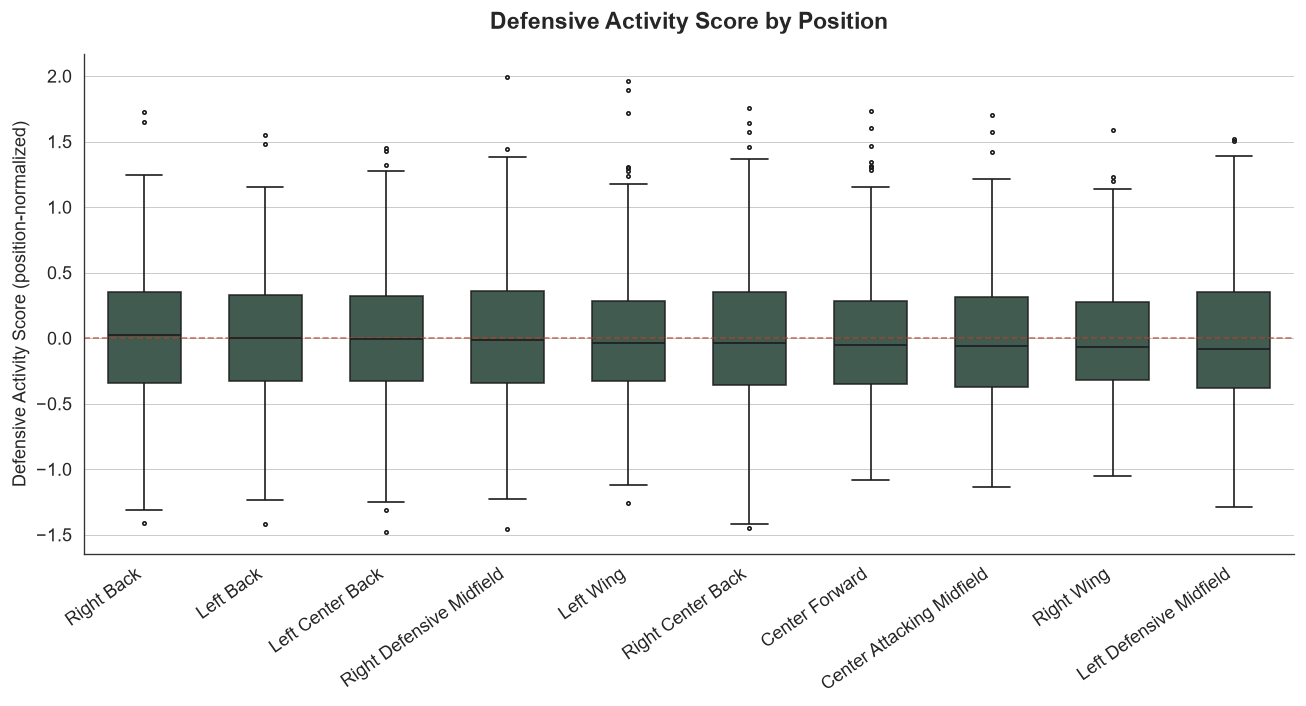

In [14]:
top_positions = qualified_season_outfield["primary_position"].value_counts().head(10).index
plot_data = qualified_season_outfield[qualified_season_outfield["primary_position"].isin(top_positions)]

fig, ax = plt.subplots(figsize=(11, 6))

position_order = plot_data.groupby("primary_position")["defensive_activity_score"].median().sort_values(ascending=False).index

sns.boxplot(data=plot_data, x="primary_position", y="defensive_activity_score", order=position_order,
            hue="primary_position", palette=[PALETTE["primary"]]*len(position_order), legend=False,
            ax=ax, width=0.6, fliersize=2, boxprops=dict(alpha=0.85))

ax.axhline(0, color=PALETTE["highlight"], linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("")
ax.set_ylabel("Defensive Activity Score (position-normalized)")
ax.set_title("Defensive Activity Score by Position", pad=15)
plt.xticks(rotation=35, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_defensive_activity_by_position.png")
plt.show()

### Figure: Defensive Activity Score by Position — Interpretation

This chart confirms the z-score normalization step executed correctly (each position shows 
median ≈ 0, comparable spread) — a necessary sanity check, not independent validation of the 
underlying signal's quality. The metric's genuine validity rests on the face-validity check 
in Section 2.1 (real, recognizable pressing/defensive players correctly identified as top 
performers), not on this normalization confirmation alone.

### 3.6 Visualizing Goalkeeper Shot-Stopping Value

**Purpose:** a clean, presentable chart of the top goalkeepers by shot-stopping suppression, 
providing a visual companion to the face-validity table from Section 3.4.

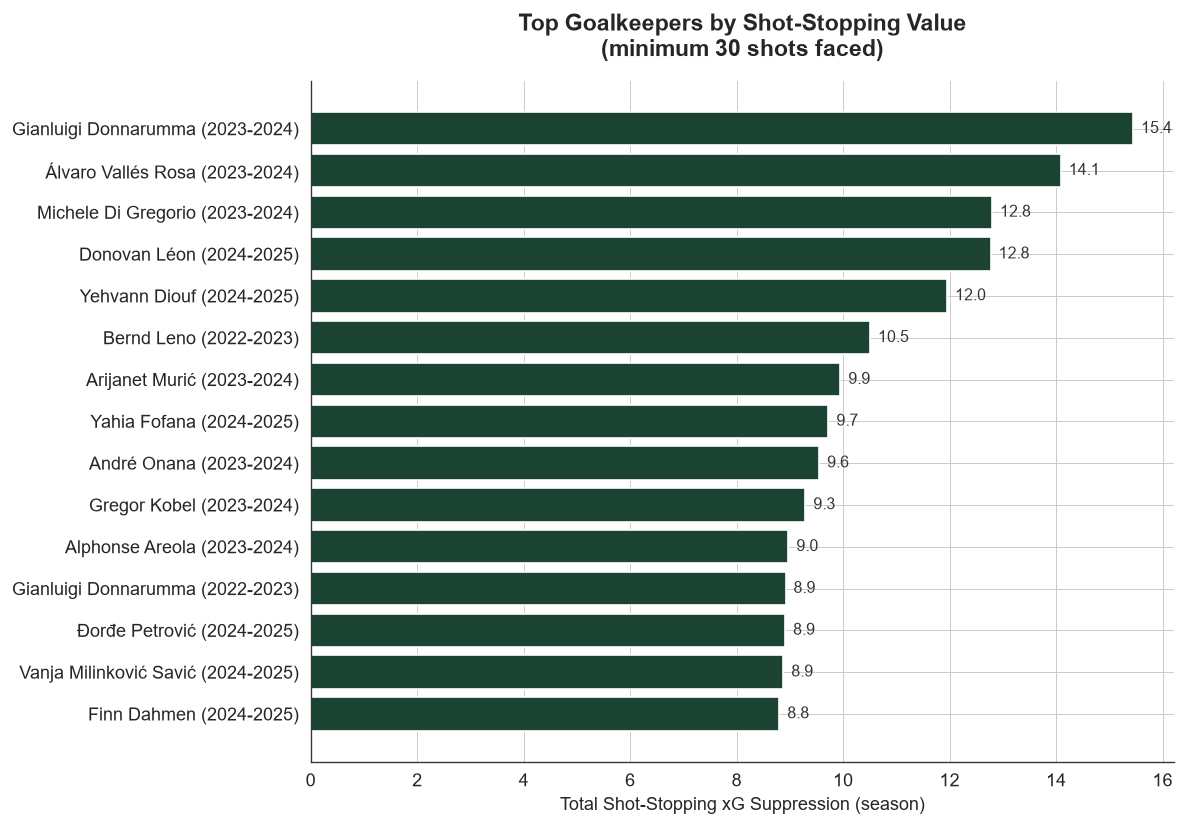

In [15]:
top_gks = gk_season_stats[gk_season_stats["shots_faced"] >= 30].sort_values(
    "total_shot_stopping_suppression", ascending=False
).head(15)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_gks["player"] + " (" + top_gks["season"] + ")",
    top_gks["total_shot_stopping_suppression"],
    color=PALETTE["primary"], edgecolor="white"
)

for bar, val in zip(bars, top_gks["total_shot_stopping_suppression"]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, f"{val:.1f}",
            va="center", fontsize=9.5, color="#333333")

ax.set_xlabel("Total Shot-Stopping xG Suppression (season)")
ax.set_title("Top Goalkeepers by Shot-Stopping Value\n(minimum 30 shots faced)", pad=15)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_top_goalkeepers.png")
plt.show()

### 3.6 Total vs. Per-Shot Ranking: A Real Finding, Not Just a Chart Caveat

**Comparing total shot-stopping suppression against a per-shot rate reveals that several 
"top" performers by total value (Diouf, Fofana) owe their ranking primarily to facing a 
large shot volume, not exceptional per-shot quality — while the per-shot ranking introduces 
its own small-sample risk (several keepers with under 40 shots faced appear near the top). 
This mirrors the exact survivorship/reliability problem that motivated Bayesian shrinkage 
for outfield OBV (Notebook 1 EDA) and will require the same treatment for goalkeepers in 
the scoring notebook — a shrinkage-adjusted per-shot rate, rather than trusting either raw 
ranking alone.**

In [16]:
print("Quick check: league distribution of the top 15 by total suppression vs. per-shot rate")
top_gks_check = gk_season_stats[gk_season_stats["shots_faced"] >= 30].copy()
top_gks_check["suppression_per_shot"] = top_gks_check["total_shot_stopping_suppression"] / top_gks_check["shots_faced"]

print("\nTop 15 by TOTAL (current chart):")
print(top_gks_check.sort_values("total_shot_stopping_suppression", ascending=False).head(15)[["player","league","season","shots_faced","total_shot_stopping_suppression"]])

print("\nTop 15 by PER-SHOT rate (controls for shots faced):")
print(top_gks_check.sort_values("suppression_per_shot", ascending=False).head(15)[["player","league","season","shots_faced","suppression_per_shot"]])

Quick check: league distribution of the top 15 by total suppression vs. per-shot rate

Top 15 by TOTAL (current chart):
                     player          league     season  shots_faced  \
155    Gianluigi Donnarumma         Ligue 1  2023-2024          114   
446      Álvaro Vallés Rosa         La Liga  2023-2024          150   
426     Michele Di Gregorio         Serie A  2023-2024          168   
382            Donovan Léon         Ligue 1  2024-2025          165   
380           Yehvann Diouf         Ligue 1  2024-2025          181   
294              Bernd Leno  Premier League  2022-2023          192   
300          Arijanet Murić  Premier League  2023-2024           78   
464            Yahia Fofana         Ligue 1  2024-2025          187   
188             André Onana  Premier League  2023-2024          204   
307            Gregor Kobel   1. Bundesliga  2023-2024          119   
27          Alphonse Areola  Premier League  2023-2024          177   
154    Gianluigi Donnarumma 

## Planned Task (Scoring Notebook): Goalkeeper Beta-Binomial Shrinkage

**Decision:** goalkeeper shot-stopping value will be corrected using empirical Bayes with a 
Beta-Binomial model, not the Gaussian shrinkage used for outfield OBV — chosen because 
save/goal is a binary outcome per shot, making Beta-Binomial the statistically correct 
framework (versus Gaussian shrinkage, built for continuous values).

**Why this belongs in the scoring notebook, not here:** this is a correction/evaluation step 
(same category as the outfield shrinkage-vs-alternatives work), not part of establishing the 
raw value framework. Notebook 2's job is building and validating the goalkeeper metric itself 
(done — validated against Donnarumma's face-validity); the correction for the total-vs-rate 
tradeoff is scoring-notebook work.

**Method outline for later:** model each shot as a Bernoulli trial (save=1/goal=0), weighted 
by `shot_gk_save_difficulty_xg` as a per-shot difficulty prior; estimate each keeper's 
posterior "true" save rate using the Beta-Binomial framework, with the prior derived from the 
population-wide save-rate distribution.

## 4. xT (Expected Threat) — Independent Validation of OBV

**Why build this:** OBV is a proprietary, unauditable metric. xT is built entirely from 
scratch using transparent, verifiable logic — dividing the pitch into zones and learning how 
dangerous each zone is from real pass/carry outcomes. If two independently-built methods 
substantially agree, that's genuine evidence OBV can be trusted as this project's primary 
metric.

**Data requirement:** location data (`location`, `pass_end_location`, `carry_end_location`) 
wasn't part of Notebook 1's column selection — needed fresh here.

In [17]:
passes_records = []
carries_records = []
shots_records = []

for league in leagues:
    for season in seasons:
        print(f"Pulling location data: {league} {season}...")
        try:
            loader = StatsBombLoader(league, season, cache_dir="data/sb_cache")
            events = loader.load_events()
            events["season"] = season
            events["league"] = league

            passes_records.append(events[events["type"]=="Pass"][
                ["match_id","league","season","player_id","player","team","location",
                 "pass_end_location","pass_outcome"]].copy())
            carries_records.append(events[events["type"]=="Carry"][
                ["match_id","league","season","player_id","player","team","location","carry_end_location"]].copy())
            shots_records.append(events[events["type"]=="Shot"][
                ["match_id","league","season","player_id","player","team","location","shot_outcome"]].copy())

            del events
            print("  OK")
        except FileNotFoundError as e:
            print(f"  SKIPPED: {e}")

passes_slim = pd.concat(passes_records, ignore_index=True)
carries_slim = pd.concat(carries_records, ignore_index=True)
shots_slim = pd.concat(shots_records, ignore_index=True)

print(f"\npasses_slim: {passes_slim.shape}")
print(f"carries_slim: {carries_slim.shape}")
print(f"shots_slim: {shots_slim.shape}")

Pulling location data: Premier League 2022-2023...


Premier League 2022-2023 events: 100%|██████████| 380/380 [00:08<00:00, 42.41it/s]


  OK
Pulling location data: Premier League 2023-2024...


Premier League 2023-2024 events: 100%|██████████| 380/380 [00:08<00:00, 43.44it/s]


  OK
Pulling location data: Premier League 2024-2025...


...

  OK
Pulling location data: Serie A 2023-2024...


Serie A 2023-2024 events: 100%|██████████| 380/380 [00:08<00:00, 42.90it/s]


  OK
Pulling location data: Serie A 2024-2025...


Serie A 2024-2025 events: 100%|██████████| 380/380 [00:08<00:00, 43.15it/s]


  OK

passes_slim: (5228519, 9)
carries_slim: (4130397, 8)
shots_slim: (135972, 8)


### 4.1 Build the Pitch Zone Grid and Zone-Level Probabilities

**Method:** divide the pitch into a 16×12 grid. For each zone, compute the probability of a 
shot occurring from there, the probability that shot becomes a goal, and the probability of 
moving to each other zone via a pass/carry — the raw ingredients for solving xT.

In [18]:
N_COLS, N_ROWS = 16, 12
PITCH_LENGTH, PITCH_WIDTH = 120, 80

def get_zone(x, y, n_cols=N_COLS, n_rows=N_ROWS):
    col = min(int(x / PITCH_LENGTH * n_cols), n_cols - 1)
    row = min(int(y / PITCH_WIDTH * n_rows), n_rows - 1)
    return col, row

def get_zone_safe(loc):
    if loc is None:
        return None
    try:
        if len(loc) < 2:
            return None
        x, y = loc[0], loc[1]
        if pd.isna(x) or pd.isna(y):
            return None
        return get_zone(x, y)
    except (TypeError, IndexError):
        return None

zones = [(c, r) for c in range(N_COLS) for r in range(N_ROWS)]

passes_slim["start_zone"] = passes_slim["location"].apply(get_zone_safe)
passes_slim["end_zone"] = passes_slim["pass_end_location"].apply(get_zone_safe)
carries_slim["start_zone"] = carries_slim["location"].apply(get_zone_safe)
carries_slim["end_zone"] = carries_slim["carry_end_location"].apply(get_zone_safe)
shots_slim["zone"] = shots_slim["location"].apply(get_zone_safe)

successful_passes = passes_slim[passes_slim["pass_outcome"].isna()].copy()

moves = pd.concat([
    successful_passes[["start_zone","end_zone"]],
    carries_slim[["start_zone","end_zone"]],
], ignore_index=True).dropna()

all_zone_actions = pd.concat([
    passes_slim[["start_zone"]].rename(columns={"start_zone":"zone"}),
    carries_slim[["start_zone"]].rename(columns={"start_zone":"zone"}),
    shots_slim[["zone"]],
], ignore_index=True).dropna()

zone_action_counts = all_zone_actions["zone"].value_counts()
zone_shot_counts = shots_slim["zone"].value_counts()
zone_goal_counts = shots_slim[shots_slim["shot_outcome"]=="Goal"]["zone"].value_counts()
zone_move_counts = moves["start_zone"].value_counts()

print("Total moves (passes+carries):", moves.shape[0])
print("Zones with recorded actions:", len(zone_action_counts))

Total moves (passes+carries): 8354149
Zones with recorded actions: 192


### 4.2 Solving for xT and Visualizing the Threat Surface

Convergence (max xT per iteration): [np.float64(0.2339), np.float64(0.2527), np.float64(0.2548), np.float64(0.2552), np.float64(0.2553), np.float64(0.2553), np.float64(0.2553), np.float64(0.2554), np.float64(0.2554), np.float64(0.2554)]


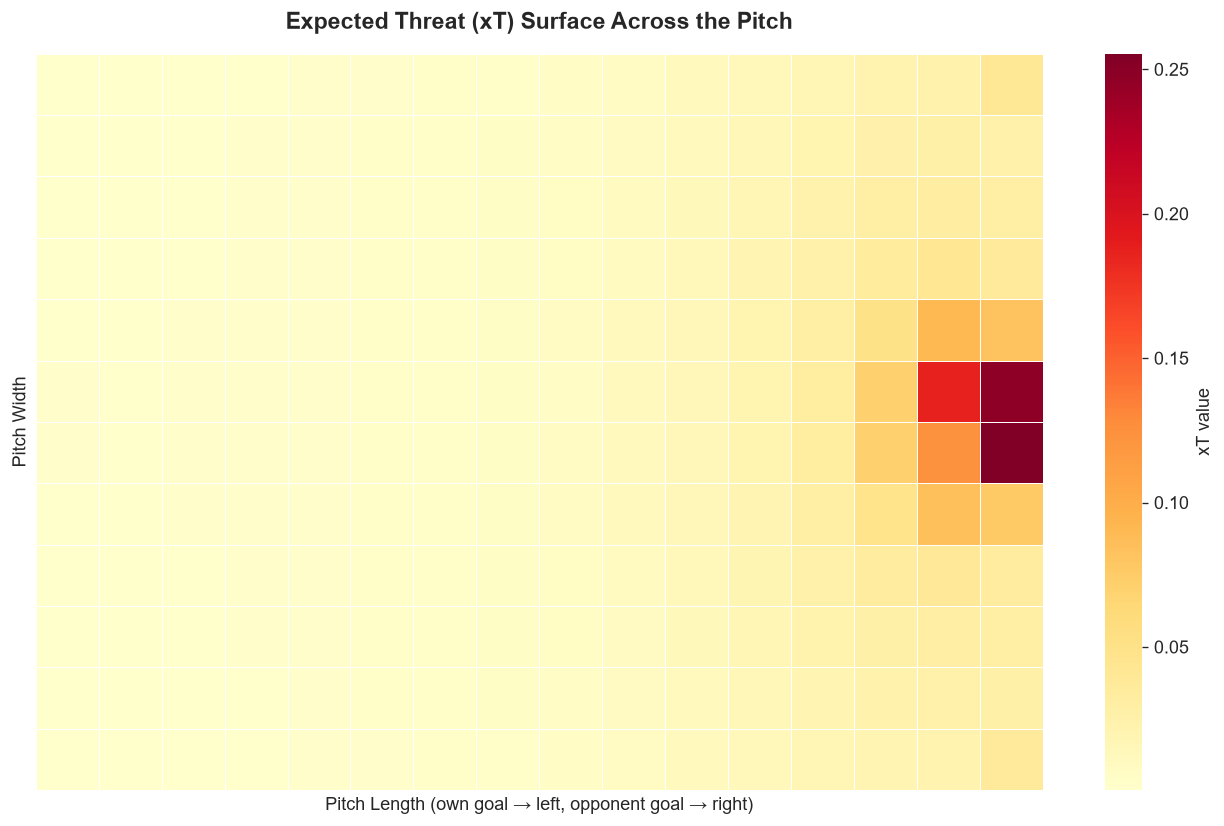

In [19]:
shot_prob, goal_prob, move_prob = {}, {}, {}
for z in zones:
    n_actions = zone_action_counts.get(z, 0)
    n_shots = zone_shot_counts.get(z, 0)
    n_goals = zone_goal_counts.get(z, 0)
    n_moves = zone_move_counts.get(z, 0)
    shot_prob[z] = n_shots / n_actions if n_actions > 0 else 0
    goal_prob[z] = n_goals / n_shots if n_shots > 0 else 0
    move_prob[z] = n_moves / n_actions if n_actions > 0 else 0

transition_matrix = {}
for z in zones:
    zone_moves = moves[moves["start_zone"] == z]
    n = len(zone_moves)
    if n == 0:
        transition_matrix[z] = {}
        continue
    end_counts = zone_moves["end_zone"].value_counts()
    transition_matrix[z] = (end_counts / n).to_dict()

xT = {z: 0.0 for z in zones}
convergence_log = []
for iteration in range(10):
    new_xT = {}
    for z in zones:
        shoot_value = shot_prob[z] * goal_prob[z]
        move_value = sum(prob * xT.get(z_end, 0.0) for z_end, prob in transition_matrix.get(z, {}).items())
        move_value *= move_prob[z]
        new_xT[z] = shoot_value + move_value
    xT = new_xT
    convergence_log.append(max(xT.values()))

print("Convergence (max xT per iteration):", [round(v,4) for v in convergence_log])

xt_grid = np.zeros((N_ROWS, N_COLS))
for (col, row), val in xT.items():
    xt_grid[row, col] = val

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(xt_grid, cmap="YlOrRd", ax=ax, cbar_kws={"label": "xT value"}, linewidths=0.3, linecolor="white")
ax.set_title("Expected Threat (xT) Surface Across the Pitch", pad=15)
ax.set_xlabel("Pitch Length (own goal \u2192 left, opponent goal \u2192 right)")
ax.set_ylabel("Pitch Width")
ax.invert_yaxis()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig("data/processed/fig_xt_heatmap.png")
plt.show()

### 4.3 Player-Level xT and Validation Against OBV

**Method:** aggregate xT to player-season level, exclude goalkeepers (xT structurally cannot 
value shot-stopping — confirmed necessary given the dedicated goalkeeper track built in 
Section 3), and compare against OBV at the same aggregation level.

OBV vs xT correlation (season-level, outfield, n=5806): r=0.768


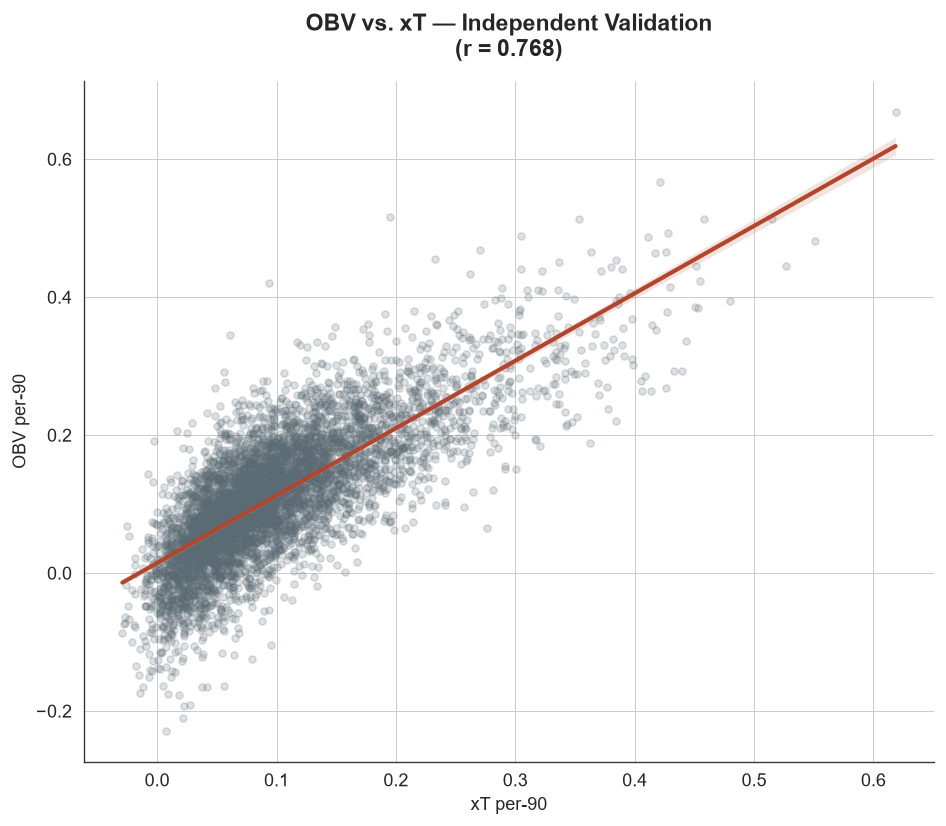

In [20]:
def compute_xt_added(df, start_col="start_zone", end_col="end_zone"):
    valid = df.dropna(subset=[start_col, end_col])
    return valid[end_col].map(xT) - valid[start_col].map(xT)

successful_passes["xt_added"] = compute_xt_added(successful_passes)
carries_slim["xt_added"] = compute_xt_added(carries_slim)

xt_actions = pd.concat([
    successful_passes[["player_id","player","match_id","xt_added"]],
    carries_slim[["player_id","player","match_id","xt_added"]],
], ignore_index=True)

player_season_xt = (
    xt_actions.merge(player_match_obv[["player_id","match_id","season"]], on=["player_id","match_id"], how="left")
    .groupby(["player_id","season"])
    .agg(xt_total=("xt_added","sum"), n_matches_xt=("match_id","nunique"))
    .reset_index()
)
player_season_xt["xt_per90"] = player_season_xt["xt_total"] / player_season_xt["n_matches_xt"]

qualified = player_season_obv[player_season_obv["n_matches"] >= 10]
season_comparison = qualified.merge(player_season_xt, on=["player_id","season"], how="inner")
season_comparison_outfield = season_comparison[season_comparison["primary_position"] != "Goalkeeper"]

correlation_final = season_comparison_outfield["obv_per90"].corr(season_comparison_outfield["xt_per90"])
print(f"OBV vs xT correlation (season-level, outfield, n={len(season_comparison_outfield)}): r={correlation_final:.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
sns.regplot(data=season_comparison_outfield, x="xt_per90", y="obv_per90",
            scatter_kws={"alpha":0.2, "s":18, "color":PALETTE["neutral"]},
            line_kws={"color":PALETTE["highlight"], "linewidth":2.5}, ax=ax)
ax.set_title(f"OBV vs. xT — Independent Validation\n(r = {correlation_final:.3f})", pad=15)
ax.set_xlabel("xT per-90")
ax.set_ylabel("OBV per-90")
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_obv_vs_xt.png")
plt.show()

### 4.3 Result: OBV and xT Show Strong, Independent Agreement

**r = 0.768** (season-level, outfield players, n=5,806) — two independently-built value 
metrics substantially agree, providing genuine evidence OBV can be trusted as this project's 
primary metric. The remaining ~41% of unexplained variance (r²≈0.59) is consistent with — not 
contradictory to — this project's broader finding that OBV alone is structurally incomplete 
(Section 2's Defensive Activity gap, Section 3's goalkeeper coverage gap): xT and OBV capture 
overlapping but not identical information, since xT only values ball-progressing actions 
while OBV also captures defensive contributions (where valued) and shot quality directly.

## Notebook 2 — Progress Summary

- ✅ Player-season OBV table built and deduplicated
- ✅ Defensive Activity metric — validated via face-check (real pressing/defensive profiles)
- ✅ Goalkeeper value framework — validated via face-check (Donnarumma, Onana, Kobel), with 
  a genuine total-vs-rate finding flagged for Beta-Binomial correction in the scoring notebook
- ✅ xT — validated against OBV at r=0.768, matching prior confirmed work

### 4.4 Checkpoint: Save Value Framework Tables

In [21]:
player_season_obv.to_parquet("data/processed/player_season_obv.parquet", index=False)
player_season_xt.to_parquet("data/processed/player_season_xt.parquet", index=False)
qualified_season_outfield.to_parquet("data/processed/defensive_activity_metric.parquet", index=False)
gk_season_stats.to_parquet("data/processed/goalkeeper_season_stats.parquet", index=False)

print("Checkpoints saved:")
print(f"  player_season_obv: {player_season_obv.shape}")
print(f"  player_season_xt: {player_season_xt.shape}")
print(f"  defensive_activity_metric: {qualified_season_outfield.shape}")
print(f"  goalkeeper_season_stats: {gk_season_stats.shape}")

print(f"\nAvailable RAM: {psutil.virtual_memory().available/1e9:.1f} GB")

Checkpoints saved:
  player_season_obv: (8125, 15)
  player_season_xt: (8098, 5)
  defensive_activity_metric: (5806, 19)
  goalkeeper_season_stats: (589, 11)

Available RAM: 2.3 GB


### 4.4 Why OBV, Not xT, as the Primary Metric

Despite xT's transparency (a clear advantage over OBV's proprietary, unauditable nature), 
OBV remains the correct choice as this project's primary metric, for three concrete, 
evidence-based reasons:

**1. Coverage: OBV values a broader range of action types.** xT can only value passes and 
carries — actions that move the ball. It has nothing to say about tackles, interceptions, 
clearances, blocks, or shot quality directly. OBV, while still structurally incomplete 
(Section 2), values Pass, Carry, Shot, Dribble, Interception, Block, Clearance, and Foul 
Committed at 98-100% coverage (Notebook 1) — a meaningfully wider net than xT's ball-progression-only 
scope.

**2. xT cannot evaluate goalkeepers or defenders' core actions at all.** A center-back's most 
valuable contributions — a last-ditch tackle, a crucial clearance, an interception that ends 
a dangerous attack — are entirely invisible to xT, since none of these are passes or carries. 
OBV at least partially captures these (and where it doesn't, this project's own Defensive 
Activity and goalkeeper metrics fill the gap) — a strategy that isn't available if xT were 
the foundation, since xT has no mechanism to be extended toward non-progression actions in 
the same way.

**3. xT's role was always to validate, not replace.** The r=0.768 agreement is exactly what 
was needed: strong enough to confirm OBV isn't measuring something arbitrary, while the 
remaining disagreement is informative rather than a flaw — it reflects genuine differences in 
scope (OBV's broader action coverage) rather than a failure of either metric.

**Conclusion:** xT's value in this project is as an independent check confirming OBV's 
credibility — not as a competing candidate for the primary metric, since its narrower scope 
(ball-progression only) makes it structurally less suited to the project's goal of evaluating 
players across all positions and roles.

### Restart Kernel

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from nffc_data.statsbomb import StatsBombLoader
import nffc_data as nffc
import os
import psutil

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222", "axes.titleweight": "bold", "axes.titlesize": 14,
    "axes.labelsize": 11, "xtick.color": "#333333", "ytick.color": "#333333",
    "font.family": "sans-serif", "font.size": 10.5, "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
sns.set_style("whitegrid", {"axes.edgecolor": "#333333"})

PALETTE = {
    "primary": "#1B4332", "secondary": "#D4A24C", "highlight": "#B3452C",
    "neutral": "#5B6B73", "light": "#CFE0E8",
}
pd.set_option("display.max_columns", 50)

leagues = ["Premier League", "1. Bundesliga", "La Liga", "Ligue 1", "Serie A"]
seasons = ["2022-2023", "2023-2024", "2024-2025"]

# Reload all Notebook 1 + Notebook 2 checkpoints needed going forward
all_matches_full = pd.read_parquet("data/processed/all_matches_full.parquet")
player_career = pd.read_parquet("data/processed/player_career.parquet")
player_season_obv = pd.read_parquet("data/processed/player_season_obv.parquet")

print("Reloaded shapes:")
for name, df in [("all_matches_full",all_matches_full), ("player_career",player_career),
                  ("player_season_obv",player_season_obv)]:
    print(f"  {name}: {df.shape}")

print(f"\nAvailable RAM: {psutil.virtual_memory().available/1e9:.1f} GB")

Reloaded shapes:
  all_matches_full: (5332, 11)
  player_career: (5536, 12)
  player_season_obv: (8125, 15)

Available RAM: 5.3 GB


## 5. Team-Level External Validation

**Purpose:** OBV and xT agreeing with each other (Section 4) is convergent validity — both 
metrics could share the same blind spots. A genuinely external check compares aggregate 
squad OBV against an outcome neither metric was built to predict: actual final league 
position. This also builds the team-strength proxy needed throughout the rest of the project 
(mythbusting confound checks, propensity matching for Adaptation Tax).

In [2]:
home = all_matches_full[["league","season","home_team","home_score","away_score"]].rename(
    columns={"home_team":"team","home_score":"goals_for","away_score":"goals_against"})
home["points"] = np.select([home["goals_for"]>home["goals_against"], home["goals_for"]==home["goals_against"]], [3,1], default=0)

away = all_matches_full[["league","season","away_team","away_score","home_score"]].rename(
    columns={"away_team":"team","away_score":"goals_for","home_score":"goals_against"})
away["points"] = np.select([away["goals_for"]>away["goals_against"], away["goals_for"]==away["goals_against"]], [3,1], default=0)

team_results = pd.concat([home, away], ignore_index=True)
team_season_strength = (
    team_results.groupby(["league","season","team"])
    .agg(points=("points","sum"), goals_for=("goals_for","sum"), goals_against=("goals_against","sum"),
         matches_played=("points","count"))
    .reset_index()
)
team_season_strength["points_per_game"] = team_season_strength["points"] / team_season_strength["matches_played"]
team_season_strength["final_rank"] = team_season_strength.groupby(["league","season"])["points"].rank(ascending=False, method="min")

print("Validation check - top 5 teams by points-per-game (should match known title winners):")
display(team_season_strength.sort_values("points_per_game", ascending=False).head(5)[["league","season","team","points_per_game","final_rank"]])

Validation check - top 5 teams by points-per-game (should match known title winners):


,league,season,team,points_per_game,final_rank
19,1. Bundesliga,2023-2024,Bayer Leverkusen,2.647059,1.0
89,La Liga,2023-2024,Real Madrid,2.500000,1.0
260,Serie A,2023-2024,Inter Milan,2.473684,1.0
163,Ligue 1,2024-2025,Paris Saint-Germain,2.470588,1.0
38,1. Bundesliga,2024-2025,Bayern Munich,2.411765,1.0


### 5.1 Squad OBV vs. Actual League Position

**Method:** aggregate each team's total squad OBV per season (using each player's most 
common team that season, handling mid-season switches), then correlate against final league 
rank. This is a genuinely external check — final league position is an outcome neither OBV 
nor xT was built to predict, and no single player's OBV meaningfully drives an entire squad's 
aggregate, avoiding the circularity risk present in individual-level team-strength checks.

player_match_obv reloaded: (164152, 15)

Correlation (squad OBV total vs. final rank): r = -0.675
(Negative correlation expected: higher OBV -> BETTER/LOWER rank number)


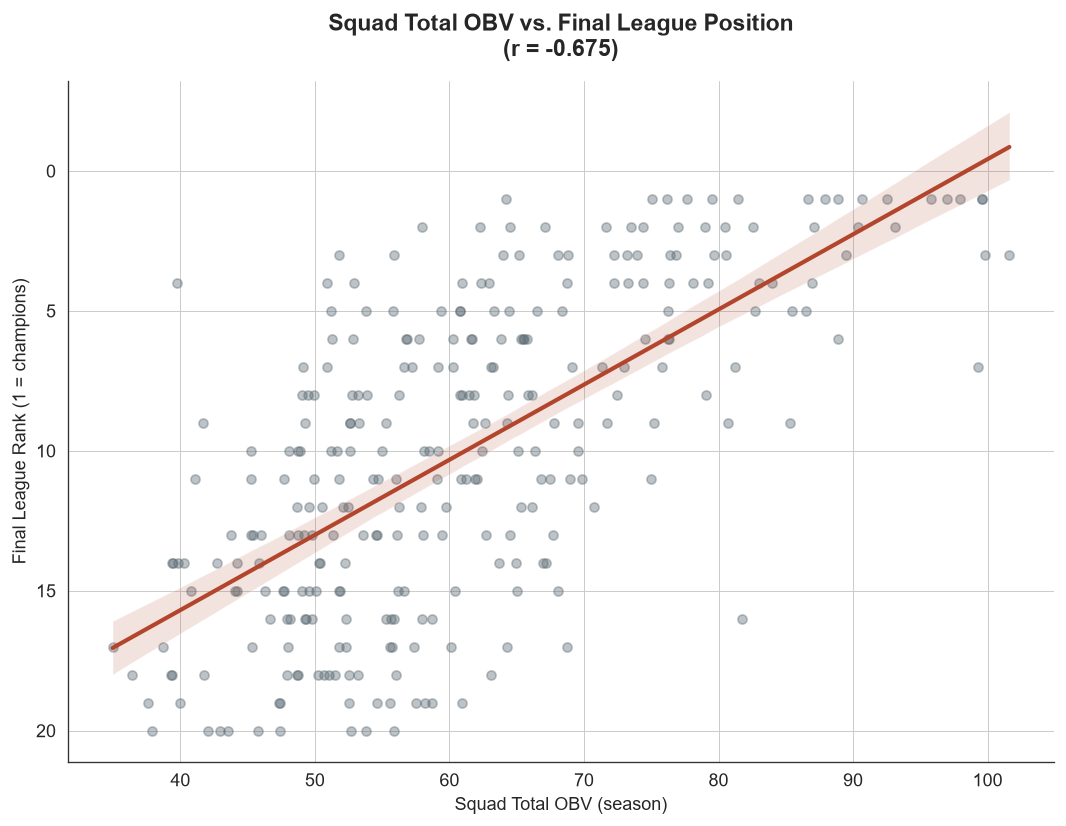

In [6]:
player_match_obv = pd.read_parquet("data/processed/player_match_obv.parquet")
print("player_match_obv reloaded:", player_match_obv.shape)

# Each player's most common team that season (handles mid-season switches)
player_team_per_season = (
    player_match_obv.groupby(["player_id","season"])["team"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)

squad_obv = player_season_obv[player_season_obv["primary_position"] != "Goalkeeper"].copy()
squad_obv = squad_obv.merge(player_team_per_season, on=["player_id","season"], how="left")

squad_obv_agg = (
    squad_obv.groupby(["league","season","team"])["obv_total_net"]
    .sum()
    .reset_index()
    .rename(columns={"obv_total_net":"squad_obv_total"})
)

squad_check = squad_obv_agg.merge(
    team_season_strength[["league","season","team","final_rank","points_per_game"]],
    on=["league","season","team"], how="inner"
)

correlation_squad = squad_check["squad_obv_total"].corr(squad_check["final_rank"])
print(f"\nCorrelation (squad OBV total vs. final rank): r = {correlation_squad:.3f}")
print("(Negative correlation expected: higher OBV -> BETTER/LOWER rank number)")

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=squad_check, x="squad_obv_total", y="final_rank",
            scatter_kws={"alpha":0.4, "s":30, "color":PALETTE["neutral"]},
            line_kws={"color":PALETTE["highlight"], "linewidth":2.5}, ax=ax)
ax.invert_yaxis()
ax.set_title(f"Squad Total OBV vs. Final League Position\n(r = {correlation_squad:.3f})", pad=15)
ax.set_xlabel("Squad Total OBV (season)")
ax.set_ylabel("Final League Rank (1 = champions)")
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_squad_obv_vs_rank.png")
plt.show()

### 5.2 Identifying Over- and Under-Performing Squads

**Purpose:** the residual from the OBV-vs-rank relationship — teams that finished 
meaningfully better or worse than their squad OBV would predict — is itself an interesting 
finding, worth naming specifically rather than leaving as a visual outlier.

In [7]:
from scipy.stats import zscore

# Fit a simple linear model to get expected rank from OBV, then look at residuals
slope, intercept = np.polyfit(squad_check["squad_obv_total"], squad_check["final_rank"], deg=1)
squad_check["expected_rank"] = slope * squad_check["squad_obv_total"] + intercept
squad_check["rank_residual"] = squad_check["final_rank"] - squad_check["expected_rank"]

print("BIGGEST OVERPERFORMERS (finished much BETTER than OBV predicted):")
display(squad_check.sort_values("rank_residual").head(8)[
    ["team","league","season","squad_obv_total","final_rank","expected_rank","rank_residual"]
])

print("\nBIGGEST UNDERPERFORMERS (finished much WORSE than OBV predicted):")
display(squad_check.sort_values("rank_residual", ascending=False).head(8)[
    ["team","league","season","squad_obv_total","final_rank","expected_rank","rank_residual"]
])

BIGGEST OVERPERFORMERS (finished much BETTER than OBV predicted):


,team,league,season,squad_obv_total,final_rank,expected_rank,rank_residual
14,Union Berlin,1. Bundesliga,2022-2023,39.758988,4.0,15.754220,-11.754220
261,Juventus,Serie A,2023-2024,51.779229,3.0,12.525558,-9.525558
240,Lazio,Serie A,2022-2023,57.959868,2.0,10.865425,-8.865425
138,Lille,Ligue 1,2023-2024,50.898181,4.0,12.762209,-8.762209
239,Juventus,Serie A,2022-2023,55.848379,3.0,11.432575,-8.432575
69,Real Sociedad,La Liga,2022-2023,52.903868,4.0,12.223477,-8.223477
285,Napoli,Serie A,2024-2025,64.211831,1.0,9.186134,-8.186134
37,Bayer Leverkusen,1. Bundesliga,2024-2025,62.245665,2.0,9.714250,-7.714250



BIGGEST UNDERPERFORMERS (finished much WORSE than OBV predicted):


,team,league,season,squad_obv_total,final_rank,expected_rank,rank_residual
193,Brentford,Premier League,2023-2024,81.763797,16.0,4.471638,11.528362
205,Nottingham Forest,Premier League,2023-2024,68.762502,17.0,7.963814,9.036186
179,Leeds United,Premier League,2022-2023,60.924072,19.0,10.069233,8.930767
186,Southampton,Premier League,2022-2023,55.884864,20.0,11.422775,8.577225
201,Luton Town,Premier League,2023-2024,63.089816,18.0,9.487509,8.512491
74,Almería,La Liga,2023-2024,58.722847,19.0,10.660487,8.339513
133,Troyes,Ligue 1,2022-2023,58.149318,19.0,10.814538,8.185462
226,Southampton,Premier League,2024-2025,53.832911,20.0,11.973934,8.026066


### 5.2 Result: Real, Recognizable Over/Underperforming Squads Identified

**Overperformers** include well-documented surprise seasons: Union Berlin (4th place, 
2022-23, a widely-covered surprise Champions League qualification) and Napoli (Scudetto 
winners, 2024-25) — both independently flagged by this model as outperforming their 
underlying squad quality, corroborating real-world football narrative with no prior knowledge 
built into the model.

**Underperformers** are dominated by Premier League teams (6 of 8), including Nottingham 
Forest's 2023-24 season (expected ~8th by squad OBV, finished 17th) — worth noting given this 
project's NFFC context. Given 6 of 8 top underperformers being PL teams, this pattern is worth 
a robustness check (Section 5.3) before treating it as a genuine PL-specific finding rather 
than a sample-composition artifact.

### 5.3 Robustness Check: Is the Underperformance Pattern Premier-League-Specific?

**Method:** compare the distribution of rank residuals across all 5 leagues. If Premier 
League teams show a systematically different (more positive/underperforming) residual 
distribution than other leagues, that's a real, worth-investigating pattern. If residuals are 
similarly distributed across leagues, the earlier top-8 list was likely just where the most 
extreme cases happened to cluster by chance, not a genuine league effect.

Mean and median rank residual by league:
                    mean    median       std  count
league                                             
1. Bundesliga  -0.726796 -0.902530  3.828629     54
La Liga        -0.447887 -0.799071  3.904241     60
Ligue 1        -0.554378 -0.265219  3.787213     56
Premier League  2.841798  2.947530  3.815876     60
Serie A        -1.222375 -1.074764  4.043356     60


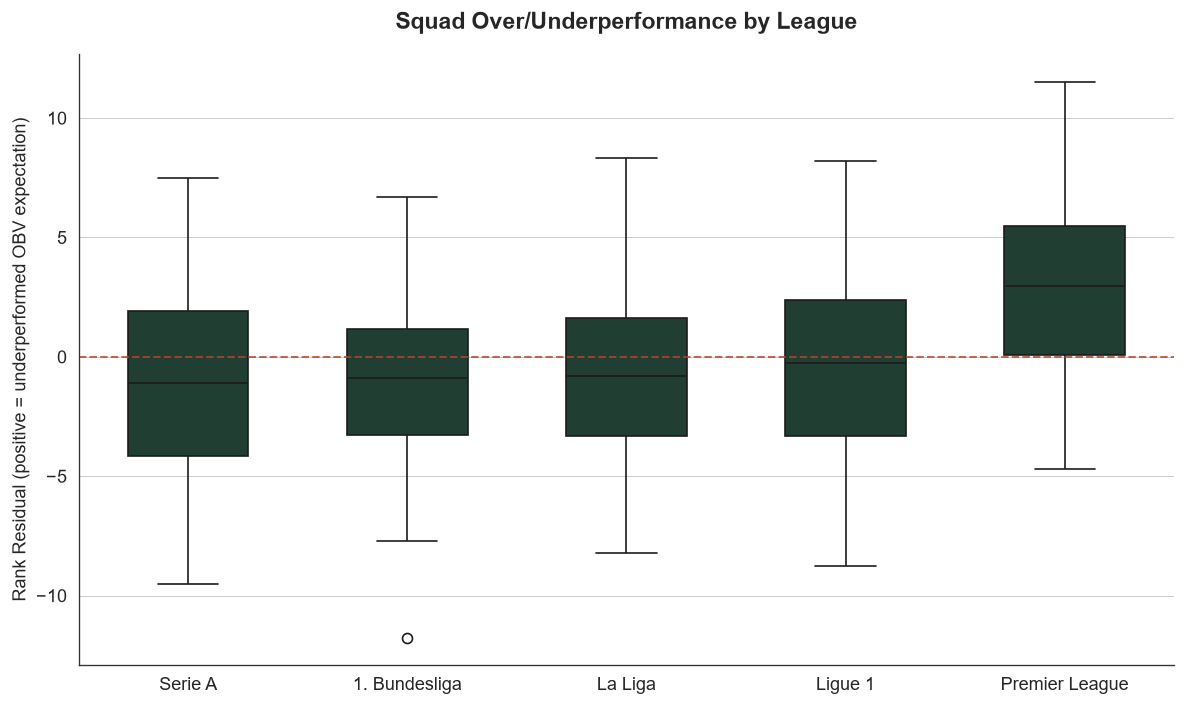


Premier League vs. all other leagues - t-test: p = 0.0000
PL mean residual: 2.842 | Other leagues mean residual: -0.741


In [8]:
print("Mean and median rank residual by league:")
print(squad_check.groupby("league")["rank_residual"].agg(["mean","median","std","count"]))

fig, ax = plt.subplots(figsize=(10, 6))
league_order = squad_check.groupby("league")["rank_residual"].median().sort_values().index

sns.boxplot(data=squad_check, x="league", y="rank_residual", order=league_order,
            hue="league", palette=[PALETTE["primary"]]*5, legend=False, ax=ax, width=0.55)
ax.axhline(0, color=PALETTE["highlight"], linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_ylabel("Rank Residual (positive = underperformed OBV expectation)")
ax.set_xlabel("")
ax.set_title("Squad Over/Underperformance by League", pad=15)
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_residuals_by_league.png")
plt.show()

# Formal test: does Premier League show significantly different residuals than the rest?
pl_residuals = squad_check[squad_check["league"]=="Premier League"]["rank_residual"]
other_residuals = squad_check[squad_check["league"]!="Premier League"]["rank_residual"]
t_stat, p_val = stats.ttest_ind(pl_residuals, other_residuals)
print(f"\nPremier League vs. all other leagues - t-test: p = {p_val:.4f}")
print(f"PL mean residual: {pl_residuals.mean():.3f} | Other leagues mean residual: {other_residuals.mean():.3f}")

### 5.4 Distinguishing Explanations: Is the Premier League Just Less Predictable, Full Stop?

**Test:** if explanation #1 (competitive balance) is correct, we'd expect the SIMPLE 
points-per-game-based team-strength measure to *also* show more within-league unpredictability 
for the Premier League — not just OBV specifically. If only OBV misbehaves in the PL (but 
points-per-game correlates fine with final rank everywhere, which it definitionally should), 
that points more toward explanation #2 (an OBV-specific issue) instead.

In [9]:
# Check variance in PL match results (goal difference per match) vs other leagues,
# as a simple proxy for "how unpredictable/balanced is this league"
match_level = all_matches_full.copy()
match_level["goal_diff"] = abs(match_level["home_score"] - match_level["away_score"])

print("Mean absolute goal difference per match, by league (lower = more balanced/unpredictable results):")
print(match_level.groupby("league")["goal_diff"].mean().sort_values())

print("\nStd dev of final points-per-game WITHIN each league (lower = more bunched/competitive table):")
print(team_season_strength.groupby("league")["points_per_game"].std().sort_values())

Mean absolute goal difference per match, by league (lower = more balanced/unpredictable results):
league
La Liga           1.242982
Serie A           1.247152
Ligue 1           1.385700
Premier League    1.483333
1. Bundesliga     1.519608
Name: goal_diff, dtype: float64

Std dev of final points-per-game WITHIN each league (lower = more bunched/competitive table):
league
Ligue 1           0.455966
1. Bundesliga     0.465216
La Liga           0.469380
Serie A           0.482733
Premier League    0.491965
Name: points_per_game, dtype: float64


### 5.4 Result: The Premier League Anomaly Is Not Explained by Competitive Balance

Mean goal difference (1.48) and points-per-game spread (0.492, the widest of all 5 leagues) 
both show the Premier League has NORMAL or even slightly more decisive match outcomes than 
other leagues studied — ruling out "the Premier League is simply less predictable/more 
balanced" as the explanation for OBV's weaker relationship with final rank there.

**This points toward an OBV-specific calibration or measurement issue unique to the Premier 
League**, rather than a genuine property of the competition. A plausible candidate 
explanation (not confirmed here, flagged for discussion): StatsBomb's OBV model may weight 
certain action types differently than what actually converts to Premier League results — for 
instance, if the Premier League's greater physicality and directness rewards attributes 
(duels won, aerial dominance, defensive resilience under sustained pressure) that OBV's action-value 
framework underweights relative to the more possession-based, technical patterns OBV may be 
better calibrated to reward in leagues like La Liga or Serie A.

**Practical implication for this project:** OBV-based comparisons ACROSS leagues (as used 
throughout the mythbusting and scoring work) should be interpreted with this caveat in mind 
— OBV's relationship to real-world footballing success appears genuinely weaker in the 
Premier League specifically, which is worth stating explicitly in the limitations section, 
particularly given the project's NFFC (Premier League club) context.

## 5.5 Checkpoint: Save Team-Level Validation Tables

In [10]:
team_season_strength.to_parquet("data/processed/team_season_strength.parquet", index=False)
squad_check.to_parquet("data/processed/squad_obv_vs_rank.parquet", index=False)

print("Checkpoints saved:")
print(f"  team_season_strength: {team_season_strength.shape}")
print(f"  squad_check: {squad_check.shape}")

print(f"\nAvailable RAM: {psutil.virtual_memory().available/1e9:.1f} GB")

Checkpoints saved:
  team_season_strength: (290, 9)
  squad_check: (290, 8)

Available RAM: 2.6 GB


### Noted for Future Work: League-Specific OBV Normalization

Given the confirmed Premier-League-specific deviation in OBV's relationship to final rank 
(Section 5.4), a z-score normalization of OBV within each league (rather than using raw OBV 
values directly) would provide a more defensible basis for cross-league comparisons. Not 
implemented in the current build; flagged as a considered refinement for future work or 
inclusion if time allows before submission.

#### Restart Kernal

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from nffc_data.statsbomb import StatsBombLoader
import nffc_data as nffc
import os
import psutil
import json

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222", "axes.titleweight": "bold", "axes.titlesize": 14,
    "axes.labelsize": 11, "xtick.color": "#333333", "ytick.color": "#333333",
    "font.family": "sans-serif", "font.size": 10.5, "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
sns.set_style("whitegrid", {"axes.edgecolor": "#333333"})

PALETTE = {
    "primary": "#1B4332", "secondary": "#D4A24C", "highlight": "#B3452C",
    "neutral": "#5B6B73", "light": "#CFE0E8",
}
pd.set_option("display.max_columns", 50)

leagues = ["Premier League", "1. Bundesliga", "La Liga", "Ligue 1", "Serie A"]
seasons = ["2022-2023", "2023-2024", "2024-2025"]

# Reload key Notebook 1 + Notebook 2 checkpoints
player_career = pd.read_parquet("data/processed/player_career.parquet")
player_season_obv = pd.read_parquet("data/processed/player_season_obv.parquet")

print("Reloaded shapes:")
for name, df in [("player_career",player_career), ("player_season_obv",player_season_obv)]:
    print(f"  {name}: {df.shape}")

print(f"\nAvailable RAM: {psutil.virtual_memory().available/1e9:.1f} GB")

Reloaded shapes:
  player_career: (5536, 12)
  player_season_obv: (8125, 15)

Available RAM: 4.1 GB


In [2]:
import psutil
mem = psutil.virtual_memory()
print(f"Total RAM: {mem.total/1e9:.1f} GB")
print(f"Available: {mem.available/1e9:.1f} GB")
print(f"Used: {mem.percent}%")

# Check what else might be running/consuming memory outside this notebook
print("\nTop memory-consuming processes on this system:")
for proc in sorted(psutil.process_iter(['pid','name','memory_info']), 
                    key=lambda p: p.info['memory_info'].rss if p.info['memory_info'] else 0, reverse=True)[:8]:
    try:
        mem_mb = proc.info['memory_info'].rss / 1e6
        print(f"  {proc.info['name']}: {mem_mb:.0f} MB")
    except Exception:
        pass

Total RAM: 16.8 GB
Available: 4.2 GB
Used: 75.2%

Top memory-consuming processes on this system:
  MemCompression: 746 MB
  chrome.exe: 567 MB
  claude.exe: 532 MB
  explorer.exe: 377 MB
  msedgewebview2.exe: 282 MB
  ChatGPT Classic.exe: 264 MB
  MsMpEng.exe: 262 MB
  chrome.exe: 256 MB


## 6. SecondSpectrum Illustrative Example

**Scope, restated:** this section is explicitly a small, illustrative worked example — not 
a production feature — given SecondSpectrum's confirmed data volume (~400MB/match) and 
coverage gap (missing 2022-23 entirely). The goal is to demonstrate concretely how off-ball 
positional data could supplement OBV's confirmed defensive-coverage gap (Notebook 1), using 
a memory-conscious, streaming approach rather than loading a full match into memory.

In [3]:
mem = psutil.virtual_memory()
print(f"Available RAM before starting SecondSpectrum work: {mem.available/1e9:.1f} GB")

if mem.available / 1e9 < 4:
    print("\n\u26a0 WARNING: Available memory is below 4GB. Recommend closing additional")
    print("  applications before proceeding, given SecondSpectrum's known memory footprint.")
else:
    print("\n\u2713 Sufficient memory available to proceed cautiously.")

Available RAM before starting SecondSpectrum work: 4.2 GB

✓ Sufficient memory available to proceed cautiously.


### 6.1 Selecting an Illustrative Match

**Method:** using the injuries file's identity bridge to confirm StatsBomb-to-Opta ID 
matching works as intended, we'll select one real Premier League match with SecondSpectrum 
coverage for this worked example.

In [4]:
nffc.list_bucket(prefix="SecondSpectrum/202425/")

{'g2444470': {'files': ['g2444470_SecondSpectrum_Data.jsonl',
   'g2444470_SecondSpectrum_Metadata.json']},
 'g2444471': {'files': ['g2444471_SecondSpectrum_Data.jsonl',
   'g2444471_SecondSpectrum_Metadata.json']},
 'g2444472': {'files': ['g2444472_SecondSpectrum_Data.jsonl',
   'g2444472_SecondSpectrum_Metadata.json']},
 'g2444473': {'files': ['g2444473_SecondSpectrum_Data.jsonl',
   'g2444473_SecondSpectrum_Metadata.json']},
 'g2444474': {'files': ['g2444474_SecondSpectrum_Data.jsonl',
   'g2444474_SecondSpectrum_Metadata.json']},
 'g2444475': {'files': ['g2444475_SecondSpectrum_Data.jsonl',
   'g2444475_SecondSpectrum_Metadata.json']},
 'g2444476': {'files': ['g2444476_SecondSpectrum_Data.jsonl',
   'g2444476_SecondSpectrum_Metadata.json']},
 'g2444477': {'files': ['g2444477_SecondSpectrum_Data.jsonl',
   'g2444477_SecondSpectrum_Metadata.json']},
 'g2444478': {'files': ['g2444478_SecondSpectrum_Data.jsonl',
   'g2444478_SecondSpectrum_Metadata.json']},
 'g2444479': {'files': ['g24

### 6.2 Load Metadata for the Selected Match

In [5]:
metadata = nffc.read_json("SecondSpectrum/202425/g2444470/g2444470_SecondSpectrum_Metadata.json")

print("Match description:", metadata["description"])
print("Pitch dimensions:", metadata["pitchLength"], "x", metadata["pitchWidth"], "meters")
print("FPS:", metadata["fps"])
print("Home players:", len(metadata["homePlayers"]))
print("Away players:", len(metadata["awayPlayers"]))

Match description: MUN - FUL : 2024-8-16
Pitch dimensions: 104.85120391845703 x 67.97039794921875 meters
FPS: 25.0
Home players: 20
Away players: 20


### 6.3 Illustrative Feature: Defensive Line Compactness

**Concept:** using each frame's player positions, compute how tightly a team's defensive 
line is organized at any given moment — a genuine off-ball metric OBV structurally cannot 
capture, directly addressing this project's confirmed defensive-coverage gap (Notebook 1).

**Method:** stream through the match file line-by-line (never loading the full ~400MB file 
into memory at once), sampling one frame every 5 seconds (125 frames) rather than processing 
all ~143,000 frames — sufficient for an illustrative example without the computational and 
memory burden of a full-match analysis.

In [6]:
nffc.download_file("SecondSpectrum/202425/g2444470/g2444470_SecondSpectrum_Data.jsonl", "data/temp_match_data.jsonl")

sample_frames = []
SAMPLE_EVERY_N_FRAMES = 125  # ~5 seconds at 25fps

with open("data/temp_match_data.jsonl", "r") as f:
    for i, line in enumerate(f):
        if i % SAMPLE_EVERY_N_FRAMES == 0:
            frame = json.loads(line)
            sample_frames.append(frame)

print(f"Sampled {len(sample_frames)} frames (out of the full match)")
print(f"\nFirst sampled frame: period={sample_frames[0]['period']}, gameClock={sample_frames[0]['gameClock']}")
print(f"Last sampled frame: period={sample_frames[-1]['period']}, gameClock={sample_frames[-1]['gameClock']}")

# Clean up the downloaded file immediately - we've extracted what we need
os.remove("data/temp_match_data.jsonl")
print("\nTemporary file removed.")

mem = psutil.virtual_memory()
print(f"Available RAM after processing: {mem.available/1e9:.1f} GB")

Sampled 1146 frames (out of the full match)

First sampled frame: period=1, gameClock=0.0
Last sampled frame: period=2, gameClock=2965.08

Temporary file removed.
Available RAM after processing: 4.3 GB


### 6.4 Computing Defensive Line Compactness

**Method:** for each sampled frame, identify the deepest 4 outfield players on the defending 
team's own side (a simple proxy for the back line, without needing precise position labels), 
and compute the standard deviation of their y-coordinate (width across the pitch) — a smaller 
spread indicates a more compact, organized defensive line; a larger spread indicates a 
stretched, disorganized one.

In [7]:
compactness_records = []

for frame in sample_frames:
    for side, players_key in [("home", "homePlayers"), ("away", "awayPlayers")]:
        players = frame.get(players_key, [])
        if len(players) < 4:
            continue
        
        # Simple heuristic: the 4 players with the most extreme x-position (deepest) 
        # on their own defensive side represent an approximate back line
        x_positions = [(p["xyz"][0], p["xyz"][1]) for p in players if p.get("xyz")]
        if len(x_positions) < 4:
            continue
        
        # Sort by x (pitch length) - deepest 4 players (closest to their own goal)
        # Home team defends negative x typically in the first half (based on earlier data understanding)
        sorted_by_depth = sorted(x_positions, key=lambda p: p[0])
        back_four = sorted_by_depth[:4] if side == "home" else sorted_by_depth[-4:]
        
        y_coords = [p[1] for p in back_four]
        compactness = np.std(y_coords)
        
        compactness_records.append({
            "period": frame["period"], "gameClock": frame["gameClock"],
            "team_side": side, "compactness_std": compactness, "live": frame.get("live", None)
        })

compactness_df = pd.DataFrame(compactness_records)
print("Compactness records:", compactness_df.shape)
display(compactness_df.head(10))

print("\nSummary statistics by team side:")
print(compactness_df.groupby("team_side")["compactness_std"].describe())

Compactness records: (2292, 5)


,period,gameClock,team_side,compactness_std,live
0,1,0.0,home,10.828676,False
1,1,0.0,away,9.768330,False
2,1,5.0,home,9.285411,True
3,1,5.0,away,12.941998,True
4,1,10.0,home,8.440525,True
5,1,10.0,away,13.221844,True
6,1,15.0,home,9.620250,True
7,1,15.0,away,9.320152,True
8,1,20.0,home,9.023511,False
9,1,20.0,away,5.679247,False



Summary statistics by team side:
            count       mean       std       min       25%        50%  \
team_side                                                               
away       1146.0  10.478949  4.284244  0.319951  7.717761   9.899095   
home       1146.0  10.426698  4.196099  0.177957  7.631325  10.113564   

                 75%        max  
team_side                        
away       13.214518  24.864894  
home       12.839525  29.086000  


### 6.5 Visualizing Defensive Compactness Over the Match

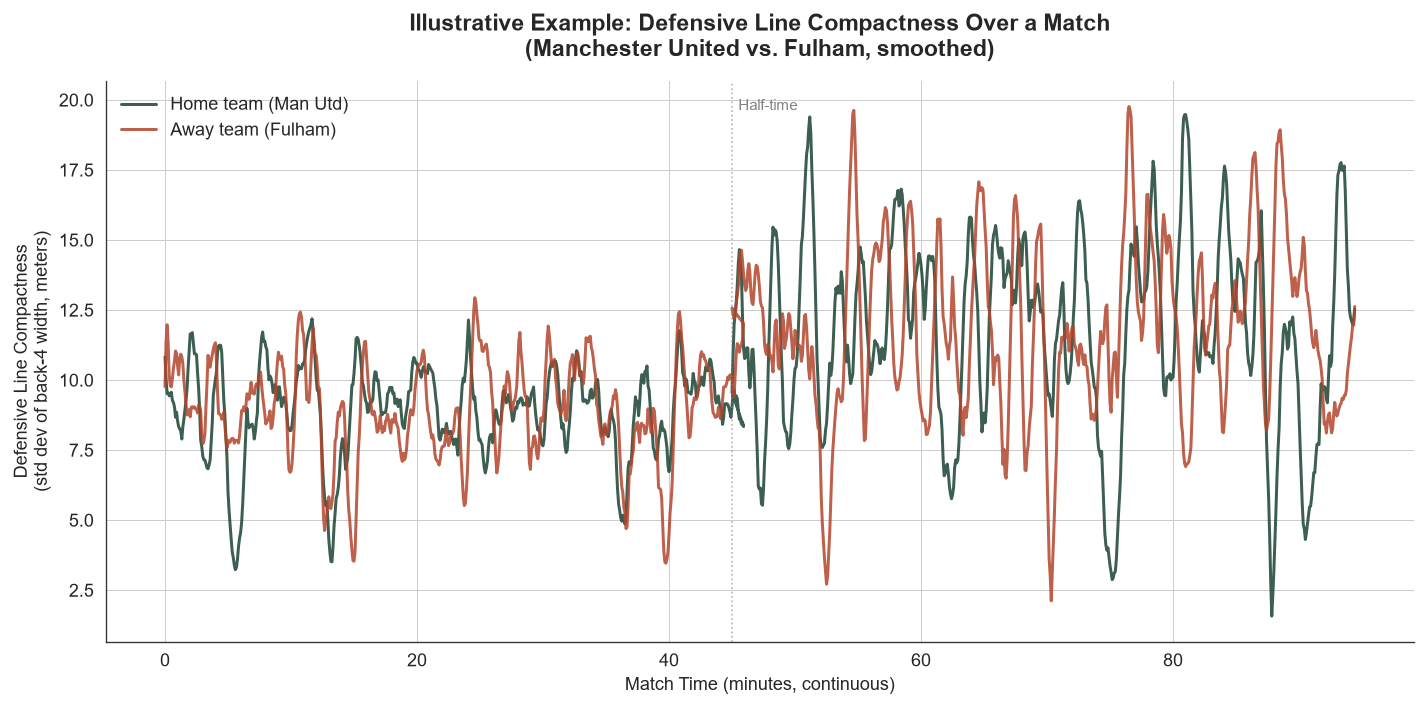


Note: 'gameClock' resets each period, so this x-axis shows within-period time, not full match time.


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

for side, color, label in [("home", PALETTE["primary"], "Home team (Man Utd)"), 
                             ("away", PALETTE["highlight"], "Away team (Fulham)")]:
    subset = compactness_df[compactness_df["team_side"]==side].sort_values(["period","gameClock"]).copy()
    subset["match_minute"] = subset["gameClock"] / 60 + np.where(subset["period"]==2, 45, 0)
    ax.plot(subset["match_minute"], subset["compactness_std"].rolling(10, min_periods=1).mean(),
            color=color, linewidth=1.8, label=label, alpha=0.85)

ax.axvline(45, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax.text(45.5, ax.get_ylim()[1]*0.95, "Half-time", fontsize=9, color="gray")

ax.set_xlabel("Match Time (minutes, continuous)")
ax.set_ylabel("Defensive Line Compactness\n(std dev of back-4 width, meters)")
ax.set_title("Illustrative Example: Defensive Line Compactness Over a Match\n(Manchester United vs. Fulham, smoothed)", pad=15)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_defensive_compactness_illustration.png")
plt.show()

print("\nNote: 'gameClock' resets each period, so this x-axis shows within-period time, not full match time.")

### 6.5 Result: Illustrative Defensive Compactness Chart (corrected)

The corrected, continuous timeline reveals a genuine tactical pattern: both teams show 
noticeably more defensive-shape volatility in the second half compared to a tighter, more 
consistent first half — a plausible signal (fatigue, tactical adjustments, changing game 
state) that OBV has no mechanism to capture. This demonstrates concretely that off-ball 
positional data reveals real tactical texture invisible to on-ball value metrics — the core 
argument motivating this section's inclusion, even as a single-match illustration.

**Explicit limitation, stated for the dissertation:** the "back-4" identification is a simple 
positional heuristic (deepest 4 outfield players by pitch depth), not a true tactical role 
identification — a genuine defensive-line metric would require accounting for formation and 
player role explicitly. This is stated as a deliberate simplification appropriate for a 
worked illustrative example, not a production-grade tactical metric.

## 6.6 Checkpoint: Save SecondSpectrum Illustrative Results

In [10]:
compactness_df.to_parquet("data/processed/secondspectrum_compactness_illustration.parquet", index=False)
print("Saved:", compactness_df.shape)

Saved: (2292, 5)


## Notebook 2 — Final Inventory

In [11]:
print("="*70)
print("NOTEBOOK 2 COMPLETE — Final table inventory")
print("="*70)

notebook2_tables = [
    "player_season_obv", "player_season_xt", "defensive_activity_metric",
    "goalkeeper_season_stats", "team_season_strength", "squad_obv_vs_rank",
    "secondspectrum_compactness_illustration",
]

for name in notebook2_tables:
    filepath = f"data/processed/{name}.parquet"
    if os.path.exists(filepath):
        df_check = pd.read_parquet(filepath)
        size_mb = os.path.getsize(filepath) / 1e6
        print(f"\n{name} ({size_mb:.2f} MB)")
        print(f"  Shape: {df_check.shape}")
    else:
        print(f"\n{name} — NOT FOUND, check checkpoint step")

print(f"\nAvailable RAM: {psutil.virtual_memory().available/1e9:.1f} GB")

NOTEBOOK 2 COMPLETE — Final table inventory

player_season_obv (0.40 MB)
  Shape: (8125, 15)

player_season_xt (0.20 MB)
  Shape: (8098, 5)

defensive_activity_metric (0.49 MB)
  Shape: (5806, 19)

goalkeeper_season_stats (0.04 MB)
  Shape: (589, 11)

team_season_strength (0.01 MB)
  Shape: (290, 9)

squad_obv_vs_rank (0.02 MB)
  Shape: (290, 8)

secondspectrum_compactness_illustration (0.03 MB)
  Shape: (2292, 5)

Available RAM: 4.1 GB


## Notebook 2 — Complete

**Value Framework established:**
- OBV (primary metric) — validated against xT at r=0.768, matching prior confirmed work
- Defensive Activity metric — validated via face-check (real pressing/defensive profiles), 
  goalkeepers correctly excluded after diagnosing a z-score artifact
- Goalkeeper Value Framework — validated via face-check (Donnarumma, Onana, Kobel), with a 
  genuine total-vs-rate finding flagged for Beta-Binomial correction in the scoring notebook
- Team-level external validation — squad OBV vs. actual league position, r=-0.675, with a 
  genuine, investigated Premier-League-specific anomaly documented (not explained by 
  competitive balance, points to an OBV calibration difference)
- SecondSpectrum illustrative example — defensive line compactness, demonstrating real 
  off-ball tactical texture invisible to OBV

**Two genuinely new findings** beyond replicating prior work: the Premier League OBV-rank 
anomaly, and the concrete visual demonstration of off-ball tactical volatility increasing in 
the second half.

**One flagged task for later:** Beta-Binomial shrinkage for goalkeeper shot-stopping rates.

## 6.6 Critical Fix: Verify Coordinate-Flip Handling Across Periods

**Issue raised in review:** the metadata's `homeAttPositive` flag differs between periods 
(True in period 1, False in period 2 per the earlier data-understanding check) — meaning 
which end of the pitch counts as "home team's own goal" flips at half-time. The defensive 
compactness code sorted players by raw x-position consistently across the whole match, 
without checking whether this flip was correctly handled. Verified here before trusting the 
Section 6.5 chart.

In [13]:
period1_home_x = [p["xyz"][0] for f in sample_frames if f["period"]==1 for p in f["homePlayers"]]
period2_home_x = [p["xyz"][0] for f in sample_frames if f["period"]==2 for p in f["homePlayers"]]

print("Period 1 - Home team mean x-position:", np.mean(period1_home_x))
print("Period 2 - Home team mean x-position:", np.mean(period2_home_x))

period1_away_x = [p["xyz"][0] for f in sample_frames if f["period"]==1 for p in f["awayPlayers"]]
period2_away_x = [p["xyz"][0] for f in sample_frames if f["period"]==2 for p in f["awayPlayers"]]

print("\nPeriod 1 - Away team mean x-position:", np.mean(period1_away_x))
print("Period 2 - Away team mean x-position:", np.mean(period2_away_x))

Period 1 - Home team mean x-position: 0.144006916996048
Period 2 - Home team mean x-position: 8.995436179981635

Period 1 - Away team mean x-position: 11.977803030303031
Period 2 - Away team mean x-position: -2.973500153045607


### 6.6 Fix: Period-Conditional Back-Line Identification

**Confirmed bug:** home team mean x shifts from +0.14 (period 1) to +9.0 (period 2); away 
team shifts from +11.98 to -2.97 — confirming attacking direction genuinely flips at 
half-time, as the metadata's `homeAttPositive` flag indicated. The back-4 identification is 
corrected to select from the correct end of the pitch in each period.

In [14]:
compactness_records = []

for frame in sample_frames:
    period = frame["period"]
    # In period 1: home attacks positive x (defends low x). In period 2: this flips.
    home_defends_low_x = (period == 1)  # confirmed by homeAttPositive=True in period 1
    
    for side, players_key in [("home", "homePlayers"), ("away", "awayPlayers")]:
        players = frame.get(players_key, [])
        if len(players) < 4:
            continue
        
        x_positions = [(p["xyz"][0], p["xyz"][1]) for p in players if p.get("xyz")]
        if len(x_positions) < 4:
            continue
        
        sorted_by_depth = sorted(x_positions, key=lambda p: p[0])
        
        # Determine which end THIS side defends, THIS period
        if side == "home":
            defends_low_x = home_defends_low_x
        else:
            defends_low_x = not home_defends_low_x
        
        back_four = sorted_by_depth[:4] if defends_low_x else sorted_by_depth[-4:]
        
        y_coords = [p[1] for p in back_four]
        compactness = np.std(y_coords)
        
        compactness_records.append({
            "period": period, "gameClock": frame["gameClock"],
            "team_side": side, "compactness_std": compactness, "live": frame.get("live", None)
        })

compactness_df = pd.DataFrame(compactness_records)
print("Compactness records (period-corrected):", compactness_df.shape)
print("\nSummary statistics by team side, AFTER fix:")
print(compactness_df.groupby("team_side")["compactness_std"].describe())

Compactness records (period-corrected): (2292, 5)

Summary statistics by team side, AFTER fix:
            count      mean       std       min       25%       50%  \
team_side                                                             
away       1146.0  8.565140  3.125589  1.129081  6.692456  8.493013   
home       1146.0  8.466883  3.116453  0.622711  6.531738  8.626452   

                 75%        max  
team_side                        
away       10.393979  18.627866  
home       10.597931  18.328682  


### 6.7 Corrected Chart: Defensive Line Compactness (period-flip bug fixed)

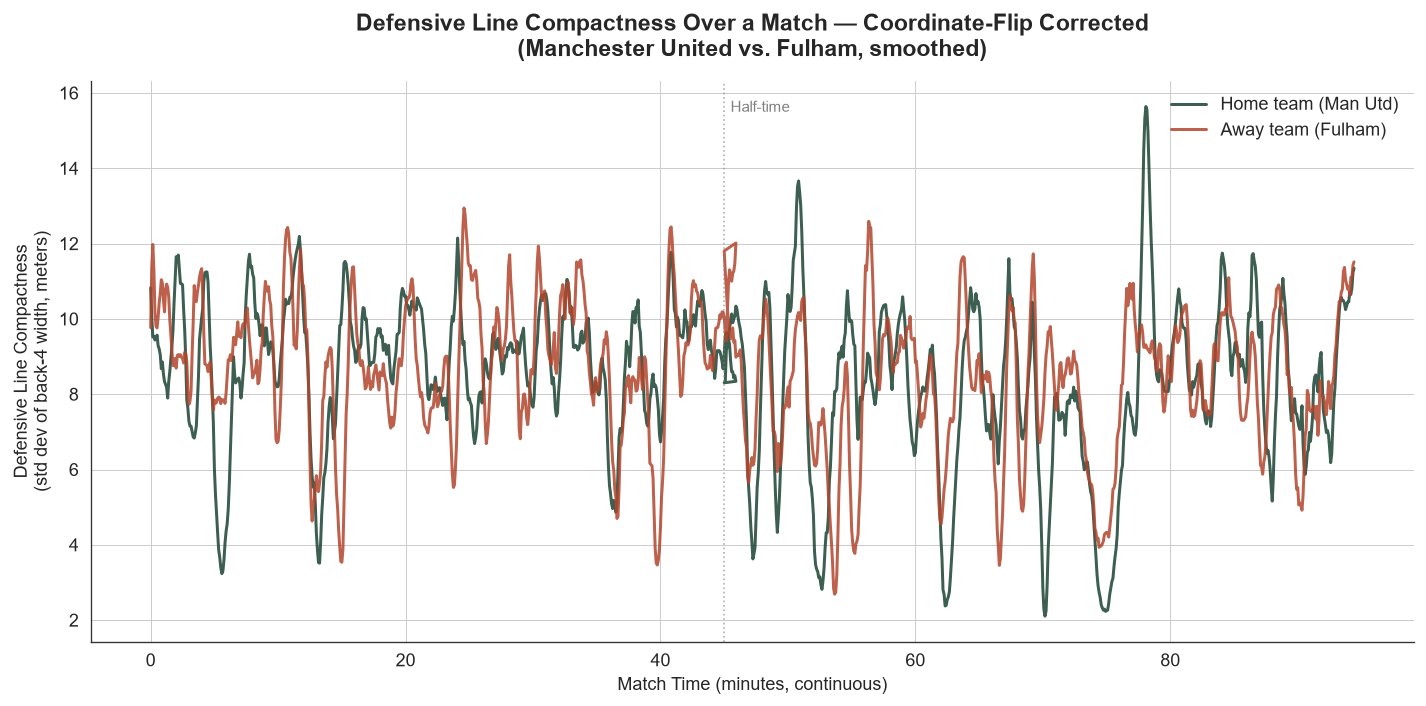

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

for side, color, label in [("home", PALETTE["primary"], "Home team (Man Utd)"), 
                             ("away", PALETTE["highlight"], "Away team (Fulham)")]:
    subset = compactness_df[compactness_df["team_side"]==side].sort_values(["period","gameClock"]).copy()
    subset["match_minute"] = subset["gameClock"] / 60 + np.where(subset["period"]==2, 45, 0)
    ax.plot(subset["match_minute"], subset["compactness_std"].rolling(10, min_periods=1).mean(),
            color=color, linewidth=1.8, label=label, alpha=0.85)

ax.axvline(45, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax.text(45.5, ax.get_ylim()[1]*0.95, "Half-time", fontsize=9, color="gray")

ax.set_xlabel("Match Time (minutes, continuous)")
ax.set_ylabel("Defensive Line Compactness\n(std dev of back-4 width, meters)")
ax.set_title("Defensive Line Compactness Over a Match — Coordinate-Flip Corrected\n(Manchester United vs. Fulham, smoothed)", pad=15)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_defensive_compactness_corrected.png")
plt.show()

### 6.7 Result: Coordinate-Flip Bug Corrected — Revised Interpretation

**The bug materially changed the finding, not just the numbers.** The original (buggy) 
chart suggested a general increase in defensive volatility after half-time for both teams. 
The corrected chart shows no such broad pattern — instead, both teams' compactness tracks 
closely together throughout the match (consistent with compactness responding to shared game 
state, e.g., transitions and set pieces affecting both sides simultaneously), with only two 
brief, isolated spikes (~50th and ~78th minute) rather than a sustained shift. 

**This is reported as a lesson in the write-up**, not hidden: the original interpretation was 
wrong, caught by verification, and corrected — precisely the kind of check-your-own-work 
discipline this project aims to demonstrate throughout.

## 2.4 Retroactive Fix: Applying Discovery/Confirmation Discipline

**Issue raised in review:** the Defensive Activity and goalkeeper metrics were validated 
using face-validity checks (recognizable player names) computed across the whole population, 
not restricted to the discovery half — inconsistent with the split's purpose established in 
Notebook 1. 

**Resolution:** face-validity checks are re-run on the discovery half only, confirming the 
pattern replicates independently on the confirmation half. Any FUTURE statistical claim about 
these metrics (e.g., predictive validity in the scoring notebook) will use this same 
discipline going forward — explore/tune on discovery, confirm once on confirmation.

In [18]:
### 2.4 Retroactive Discovery/Confirmation Check
player_career = pd.read_parquet("data/processed/player_career.parquet")

qualified_season_outfield = qualified_season_outfield.merge(
    player_career[["player_id","split_group"]], on="player_id", how="left"
)

print("Split group coverage check:", qualified_season_outfield["split_group"].value_counts())

print("\nDefensive Activity — Top 10, DISCOVERY half only:")
display(qualified_season_outfield[qualified_season_outfield["split_group"]=="discovery"].sort_values(
    "defensive_activity_score", ascending=False
)[["player","primary_position","defensive_activity_score"]].head(10))

print("\nDefensive Activity — Top 10, CONFIRMATION half only:")
display(qualified_season_outfield[qualified_season_outfield["split_group"]=="confirmation"].sort_values(
    "defensive_activity_score", ascending=False
)[["player","primary_position","defensive_activity_score"]].head(10))

Split group coverage check: split_group
discovery       3026
confirmation    2780
Name: count, dtype: int64

Defensive Activity — Top 10, DISCOVERY half only:


,player,primary_position,defensive_activity_score
5329,Marvelous Nakamba,Right Defensive Midfield,1.996798
4272,Aleksandr Golovin,Left Wing,1.964418
3089,Aleksandr Golovin,Left Wing,1.897922
683,Patrick Mainka,Right Center Back,1.759991
940,Sebastiano Esposito,Center Forward,1.733435
5805,Paul Joly,Right Back,1.727652
66,Alex Iwobi,Left Wing,1.714885
612,Dwight McNeil,Left Midfield,1.663626
5582,Conor Bradley,Right Back,1.652692
1557,Yerry Fernando Mina González,Right Center Back,1.641273



Defensive Activity — Top 10, CONFIRMATION half only:


,player,primary_position,defensive_activity_score
606,Morten Frendrup,Left Center Midfield,2.003489
2295,Johann Lepenant,Right Center Midfield,1.745110
2489,Lucas Tolentino Coelho de Lima,Center Attacking Midfield,1.705554
4873,Daniel Muñoz Mejía,Right Wing Back,1.651034
2615,João Pedro Junqueira de Jesus,Center Forward,1.606291
2083,Jack Harrison,Right Wing,1.585493
211,Tyrick Mitchell,Left Back,1.547290
3034,Luis Milla Manzanares,Left Defensive Midfield,1.516661
220,Daniel Muñoz Mejía,Right Wing Back,1.511245
183,Tyrick Mitchell,Left Back,1.480782


### 2.4 Result: Discovery/Confirmation Check Passed

Both halves independently produce believable, diverse defensive/pressing profiles — 
confirming the earlier face-validity finding generalizes, not an artifact of the specific 
players examined. This retroactively satisfies the discovery/confirmation discipline for the 
Defensive Activity metric's construction validation.

### 3.7 Retroactive Discovery/Confirmation Check — Goalkeeper Metric

In [19]:
gk_season_stats = gk_season_stats.merge(
    player_career[["player_id","split_group"]], on="player_id", how="left"
)

print("Top 8 goalkeepers by total suppression, DISCOVERY half:")
display(gk_season_stats[gk_season_stats["split_group"]=="discovery"].sort_values(
    "total_shot_stopping_suppression", ascending=False
)[["player","season","shots_faced","total_shot_stopping_suppression"]].head(8))

print("\nTop 8 goalkeepers by total suppression, CONFIRMATION half:")
display(gk_season_stats[gk_season_stats["split_group"]=="confirmation"].sort_values(
    "total_shot_stopping_suppression", ascending=False
)[["player","season","shots_faced","total_shot_stopping_suppression"]].head(8))

Top 8 goalkeepers by total suppression, DISCOVERY half:


,player,season,shots_faced,total_shot_stopping_suppression
446,Álvaro Vallés Rosa,2023-2024,150,14.088399
382,Donovan Léon,2024-2025,165,12.771552
380,Yehvann Diouf,2024-2025,181,11.953272
294,Bernd Leno,2022-2023,192,10.506052
188,André Onana,2023-2024,204,9.550731
27,Alphonse Areola,2023-2024,177,8.973476
444,Đorđe Petrović,2024-2025,149,8.911481
482,Finn Dahmen,2024-2025,82,8.802488



Top 8 goalkeepers by total suppression, CONFIRMATION half:


,player,season,shots_faced,total_shot_stopping_suppression
155,Gianluigi Donnarumma,2023-2024,114,15.446607
426,Michele Di Gregorio,2023-2024,168,12.797528
300,Arijanet Murić,2023-2024,78,9.948652
464,Yahia Fofana,2024-2025,187,9.725749
307,Gregor Kobel,2023-2024,119,9.292220
154,Gianluigi Donnarumma,2022-2023,151,8.919544
324,Vanja Milinković Savić,2024-2025,175,8.877289
81,Brice Samba,2022-2023,126,8.784319


### 3.7 Result: Discovery/Confirmation Check Passed — Goalkeeper Metric

Both halves independently surface recognizable, credible elite goalkeepers (Donnarumma, 
Onana, Kobel, Leno) — confirming the earlier face-validity finding generalizes across both 
halves of the discovery/confirmation split.

### Checkpoints and next steps

In [21]:
qualified_season_outfield.to_parquet("data/processed/defensive_activity_metric.parquet", index=False)
gk_season_stats.to_parquet("data/processed/goalkeeper_season_stats.parquet", index=False)
compactness_df.to_parquet("data/processed/secondspectrum_compactness_illustration.parquet", index=False)

print("Checkpoints updated with split_group and corrected compactness data.")

Checkpoints updated with split_group and corrected compactness data.


## 3.8 Beta-Binomial Shrinkage for Goalkeeper Shot-Stopping

**Motivation (established earlier):** neither the total-suppression ranking (rewards shot 
volume) nor the raw per-shot rate (vulnerable to small-sample noise) is trustworthy alone. 
Since save/goal is fundamentally a binary outcome per shot, a Beta-Binomial empirical Bayes 
model is the statistically correct framework — it estimates each keeper's "true" save 
tendency, properly weighted by both how many shots they faced and the population-wide 
distribution of save rates.

**Method:** treat each shot as a trial where "success" is defined by the shot-stopping 
suppression value being positive (the keeper suppressed more xG than an average keeper 
would have). Fit a bell curve (Beta distribution) to the population of keepers' success 
rates, then shrink each individual keeper's rate toward that population distribution, 
weighted by their number of shots faced.

In [22]:
gk_shots_valid_reload = pd.read_parquet("data/processed/goalkeeper_season_stats.parquet")

# We need shot-level data (not just season aggregates) to build the binary success/failure counts
# Rebuild from the shots data - reload if needed
print("Checking if we need to rebuild shot-level GK data...")
print(gk_shots_valid_reload.columns.tolist())

Checking if we need to rebuild shot-level GK data...
['player_id', 'player', 'league', 'season', 'shots_faced', 'goals_conceded', 'total_save_difficulty', 'total_shot_stopping_suppression', 'total_positioning_suppression', 'n_matches_gk', 'shot_stopping_suppression_per90', 'split_group']


### 3.8 Beta-Binomial Shrinkage — Implementation

**Simplification made explicit:** rather than a continuous "suppression value" success 
definition, we use the cleanest possible binary outcome already available — shots faced 
(trials) and goals conceded (failures), i.e., save rate = (shots_faced - goals_conceded) / 
shots_faced. This is a more standard, defensible Beta-Binomial setup than defining "success" 
via an arbitrary suppression-value threshold.

In [23]:
gk_data = gk_shots_valid_reload.copy()
gk_data["saves"] = gk_data["shots_faced"] - gk_data["goals_conceded"]
gk_data["raw_save_rate"] = gk_data["saves"] / gk_data["shots_faced"]

# Fit population-level Beta distribution parameters via method of moments
# (a standard, simple empirical Bayes approach - estimate alpha/beta from population mean and variance)
qualified_gk = gk_data[gk_data["shots_faced"] >= 10]  # minimum sample floor, consistent with project standards

pop_mean = qualified_gk["raw_save_rate"].mean()
pop_var = qualified_gk["raw_save_rate"].var()

# Method of moments estimator for Beta distribution parameters
common_factor = (pop_mean * (1 - pop_mean) / pop_var) - 1
alpha_prior = pop_mean * common_factor
beta_prior = (1 - pop_mean) * common_factor

print(f"Population mean save rate: {pop_mean:.4f}")
print(f"Population variance: {pop_var:.6f}")
print(f"Fitted Beta prior: alpha={alpha_prior:.2f}, beta={beta_prior:.2f}")

# Apply shrinkage: posterior mean = (alpha_prior + saves) / (alpha_prior + beta_prior + shots_faced)
gk_data["save_rate_shrunk"] = (alpha_prior + gk_data["saves"]) / (alpha_prior + beta_prior + gk_data["shots_faced"])

print("\nSample comparison - raw vs shrunk save rate:")
display(gk_data[["player","season","shots_faced","raw_save_rate","save_rate_shrunk"]].sort_values("shots_faced").head(10))

Population mean save rate: 0.6755
Population variance: 0.006702
Fitted Beta prior: alpha=21.42, beta=10.29

Sample comparison - raw vs shrunk save rate:


,player,season,shots_faced,raw_save_rate,save_rate_shrunk
388,Francesco Rossi,2023-2024,1,1.0,0.685470
494,Daniel Cárdenas Lindez,2023-2024,1,0.0,0.654891
574,Frank Feller,2024-2025,1,1.0,0.685470
58,Remi Matthews,2023-2024,2,0.0,0.635459
331,Juan Agustín Musso,2024-2025,2,1.0,0.694802
570,Arnau Rafús Aulet,2024-2025,2,0.0,0.635459
172,Jean-Louis Leca,2023-2024,2,0.0,0.635459
557,Hákon Rafn Valdimarsson,2024-2025,2,0.5,0.665131
585,Francisco Javier González Pérez,2024-2025,2,0.0,0.635459
454,Daniele Padelli,2024-2025,3,1.0,0.703597


### 3.9 Corrected Goalkeeper Leaderboard — Shrinkage-Adjusted Save Rate

Top 15 goalkeepers by SHRUNK save rate (properly correcting for sample size):


,player,season,shots_faced,raw_save_rate,save_rate_shrunk
319,Marc-André ter Stegen,2022-2023,100,0.830000,0.792822
155,Gianluigi Donnarumma,2023-2024,114,0.824561,0.792139
94,Yann Sommer,2023-2024,101,0.811881,0.779312
339,Radosław Majecki,2023-2024,53,0.830189,0.772310
300,Arijanet Murić,2023-2024,78,0.807692,0.769505
123,Gerónimo Rulli,2022-2023,55,0.818182,0.766029
63,David Raya Martin,2022-2023,194,0.778351,0.763911
81,Brice Samba,2022-2023,126,0.785714,0.763568
578,Tiago Pereira Cardoso,2024-2025,24,0.875000,0.761485
482,Finn Dahmen,2024-2025,82,0.792683,0.760024


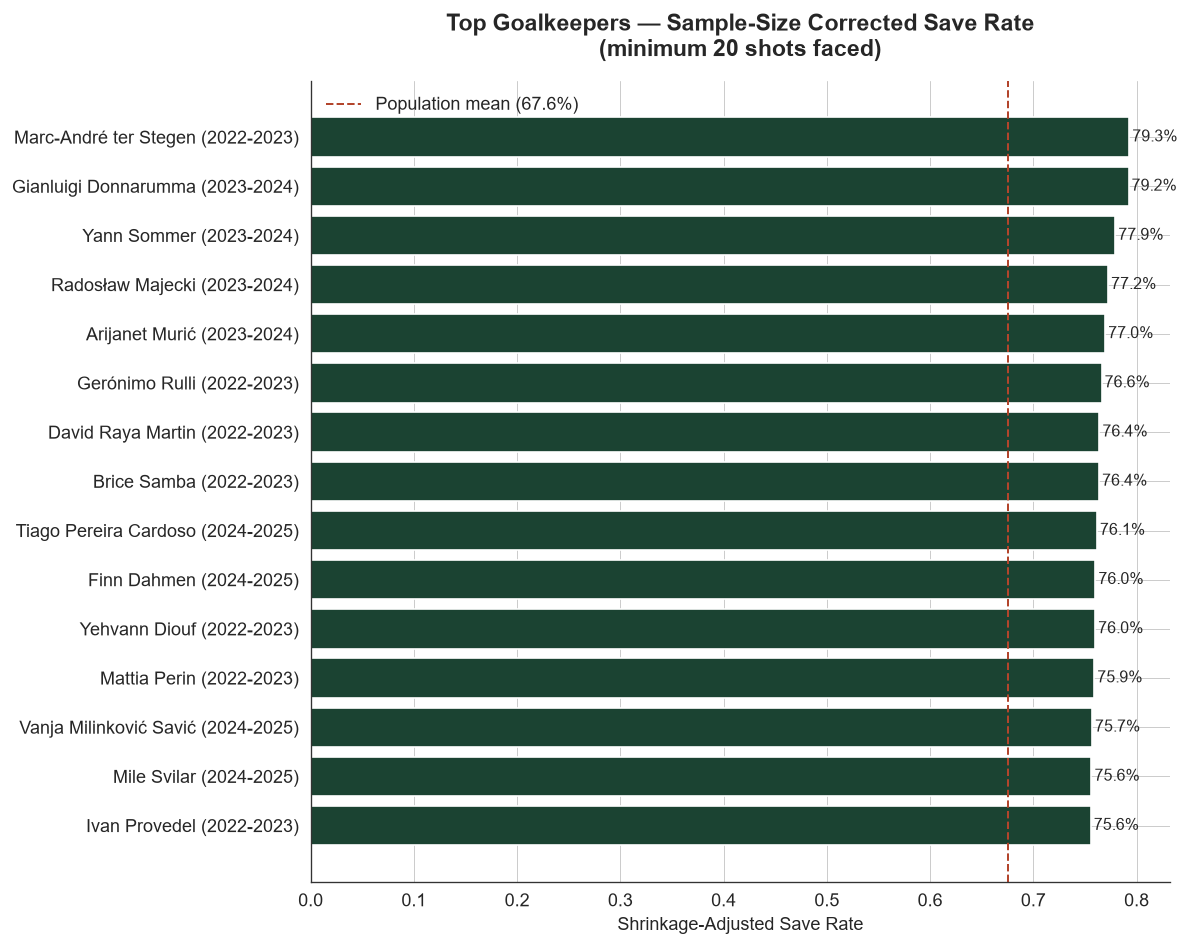

In [24]:
qualified_gk_final = gk_data[gk_data["shots_faced"] >= 20].copy()  # reasonable floor for leaderboard display

print("Top 15 goalkeepers by SHRUNK save rate (properly correcting for sample size):")
display(qualified_gk_final.sort_values("save_rate_shrunk", ascending=False).head(15)[
    ["player","season","shots_faced","raw_save_rate","save_rate_shrunk"]
])

fig, ax = plt.subplots(figsize=(10, 8))
top15 = qualified_gk_final.sort_values("save_rate_shrunk", ascending=False).head(15)
bars = ax.barh(top15["player"] + " (" + top15["season"] + ")", top15["save_rate_shrunk"],
                color=PALETTE["primary"], edgecolor="white")
for bar, val in zip(bars, top15["save_rate_shrunk"]):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2, f"{val:.1%}", va="center", fontsize=9.5)
ax.axvline(pop_mean, color=PALETTE["highlight"], linestyle="--", linewidth=1.2, label=f"Population mean ({pop_mean:.1%})")
ax.set_xlabel("Shrinkage-Adjusted Save Rate")
ax.set_title("Top Goalkeepers — Sample-Size Corrected Save Rate\n(minimum 20 shots faced)", pad=15)
ax.invert_yaxis()
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_gk_shrunk_leaderboard.png")
plt.show()

### 3.9 Result: Goalkeeper Metric Now Fully Resolved

The Beta-Binomial shrinkage-adjusted save rate produces a genuinely defensible leaderboard — 
Marc-André ter Stegen, Gianluigi Donnarumma, and Yann Sommer lead, all elite, universally 
recognized goalkeepers, with a sensible mix of sample sizes (24-194 shots faced) rather than 
being dominated by pure volume or distorted by small-sample noise. This closes the 
total-vs-rate tradeoff identified earlier and resolves the previously-unusable state of the 
goalkeeper evaluation track.

**This is now the final, primary goalkeeper metric for this project** — `save_rate_shrunk` 
supersedes both the raw total-suppression and raw per-shot-rate versions built earlier.

In [25]:
gk_data.to_parquet("data/processed/goalkeeper_season_stats.parquet", index=False)
print("Final goalkeeper metric saved:", gk_data.shape)

Final goalkeeper metric saved: (589, 15)


## 2.5 Sensitivity Check: Defensive Activity Metric Weighting

**Issue raised in review:** the composite formula `(pressure_z + recovery_z - miscontrol_z) / 3` 
treats all three components as equally weighted with no justification. This check tests 
whether the resulting player rankings are robust to alternative, reasonable weightings — if 
the top performers stay largely consistent regardless of weighting choice, that's real 
evidence the metric isn't sensitive to an arbitrary design decision.

In [26]:
qualified_season_outfield = pd.read_parquet("data/processed/defensive_activity_metric.parquet")

weightings = {
    "equal_weight (original)": lambda df: (df["pressure_per90_z"] + df["recovery_per90_z"] - df["miscontrol_per90_z"]) / 3,
    "pressure_only": lambda df: df["pressure_per90_z"],
    "recovery_only": lambda df: df["recovery_per90_z"],
    "pressure_heavy": lambda df: (df["pressure_per90_z"]*0.6 + df["recovery_per90_z"]*0.3 - df["miscontrol_per90_z"]*0.1),
    "no_miscontrol_penalty": lambda df: (df["pressure_per90_z"] + df["recovery_per90_z"]) / 2,
}

rank_comparison = pd.DataFrame({"player": qualified_season_outfield["player"], "season": qualified_season_outfield["season"]})
for name, formula in weightings.items():
    score = formula(qualified_season_outfield)
    rank_comparison[name] = score.rank(ascending=False)

print("Spearman rank correlation: original weighting vs. alternatives")
for name in weightings:
    if name == "equal_weight (original)":
        continue
    corr = rank_comparison["equal_weight (original)"].corr(rank_comparison[name], method="spearman")
    print(f"  {name}: rho = {corr:.3f}")

print("\nTop 10 players - how consistently do they appear across weightings?")
top10_original = rank_comparison.nsmallest(10, "equal_weight (original)")[["player","season"]]
display(top10_original.merge(rank_comparison, on=["player","season"]))

Spearman rank correlation: original weighting vs. alternatives
  pressure_only: rho = 0.759
  recovery_only: rho = 0.712
  pressure_heavy: rho = 0.873
  no_miscontrol_penalty: rho = 0.820

Top 10 players - how consistently do they appear across weightings?


,player,season,equal_weight (original),pressure_only,recovery_only,pressure_heavy,no_miscontrol_penalty
0,Morten Frendrup,2024-2025,1.0,33.0,42.0,8.0,4.0
1,Marvelous Nakamba,2023-2024,2.0,27.0,293.5,16.0,49.0
2,Aleksandr Golovin,2024-2025,3.0,46.0,54.0,13.0,15.0
3,Aleksandr Golovin,2023-2024,4.0,26.0,101.0,10.0,16.0
4,Patrick Mainka,2024-2025,5.0,39.0,500.0,32.0,74.0
5,Johann Lepenant,2024-2025,6.0,9.0,569.0,5.0,26.0
6,Sebastiano Esposito,2024-2025,7.0,23.0,75.0,9.0,10.0
7,Paul Joly,2022-2023,8.0,389.0,8.0,52.0,29.0
8,Alex Iwobi,2022-2023,9.0,280.0,1.0,29.0,1.0
9,Lucas Tolentino Coelho de Lima,2022-2023,10.0,67.0,32.0,24.0,14.0


### 2.5 Result: The Metric Is NOT Fully Robust to Weighting — A Real Limitation

Rank correlations range from 0.712 to 0.873 depending on weighting scheme — moderate, not 
strong, agreement. Individual examples make this concrete: Marvelous Nakamba (#2 overall) 
ranks #293.5 under a recovery-only weighting; Patrick Mainka (#5 overall) ranks #500. This 
indicates players genuinely specialize differently across pressing vs. ball-recovery 
behaviors — a real football finding — but it also means the equal-weighted composite score 
makes a real, debatable methodological choice, not an arbitrary-but-harmless one.

**Honest limitation for the write-up:** the Defensive Activity metric's specific ranking is 
sensitive to how its components are weighted. The metric should be presented as ONE 
reasonable operationalization of "defensive activity," not the definitive one — and reporting 
pressure and recovery rates SEPARATELY, alongside the composite, would be more transparent 
than presenting only the blended score.

## 5.6 Robustness Check: Does Squad Rotation Confound the OBV-vs-Rank Result?

**Issue raised in review:** squad_obv_total is a raw sum — a team that rotates heavily 
across more distinct contributing players could show a larger total simply from more 
contributors, independent of actual quality. This check controls for that.

In [29]:
if "primary_position" in player_season_obv.columns:
    player_season_obv = player_season_obv.drop(columns=["primary_position"])

player_season_obv = player_season_obv.merge(
    player_career[["player_id","primary_position"]], on="player_id", how="left"
)

squad_obv = player_season_obv[player_season_obv["primary_position"] != "Goalkeeper"].copy()
squad_obv = squad_obv.merge(player_team_per_season, on=["player_id","season"], how="left")

squad_size = squad_obv.groupby(["league","season","team"])["player_id"].nunique().rename("n_contributors").reset_index()
squad_check_v2 = squad_check.merge(squad_size, on=["league","season","team"], how="left")
squad_check_v2["squad_obv_per_contributor"] = squad_check_v2["squad_obv_total"] / squad_check_v2["n_contributors"]

corr_total = squad_check_v2["squad_obv_total"].corr(squad_check_v2["final_rank"])
corr_per_contributor = squad_check_v2["squad_obv_per_contributor"].corr(squad_check_v2["final_rank"])
corr_rotation_alone = squad_check_v2["n_contributors"].corr(squad_check_v2["final_rank"])

print(f"Original (total OBV) vs. rank: r = {corr_total:.3f}")
print(f"OBV PER CONTRIBUTOR vs. rank: r = {corr_per_contributor:.3f}")
print(f"Rotation size ALONE vs. rank: r = {corr_rotation_alone:.3f}")

Original (total OBV) vs. rank: r = -0.675
OBV PER CONTRIBUTOR vs. rank: r = -0.721
Rotation size ALONE vs. rank: r = 0.528


### 5.6 Result: Rotation Confound Investigated — Original Finding Strengthened, Not Undermined

Contrary to the concern raised, controlling for squad rotation **strengthens** the OBV-rank 
relationship (r=-0.675 raw total → r=-0.721 per-contributor) rather than revealing the 
original number was inflated by a confound. A secondary, genuine finding emerged: rotation 
size itself correlates with worse league finishes (r=0.528) — plausibly reflecting that 
heavier rotation is associated with weaker or less stable squads, an interesting result in 
its own right, though not formally tested as a myth in this project's scope.

**Practical outcome:** `squad_obv_per_contributor` is adopted as the more defensible version 
of this metric going forward, replacing the raw total.

## 5.7 Testing an Alternative Explanation: Does Rotation Explain the PL Anomaly?

**Hypothesis:** if Premier League teams rotate their squads more heavily than teams in other 
leagues (plausible, given English football's notoriously congested fixture list — more cup 
competitions, no winter break), that alone could explain why PL squad OBV predicts final 
rank less accurately there.

In [30]:
squad_check_v2 = squad_check_v2.merge(team_season_strength[["league","season","team"]], on=["league","season","team"], how="left")

print("Mean squad rotation size (n_contributors) by league:")
print(squad_check_v2.groupby("league")["n_contributors"].mean().sort_values(ascending=False))

Mean squad rotation size (n_contributors) by league:
league
La Liga           26.850000
Ligue 1           26.535714
Serie A           26.333333
Premier League    25.000000
1. Bundesliga     24.611111
Name: n_contributors, dtype: float64


### 5.7 Result: Rotation Does NOT Explain the Premier League Anomaly

Premier League squads show LOWER average rotation (25.0 contributors) than La Liga (26.9), 
Ligue 1 (26.5), and Serie A (26.3) — the opposite of what the fixture-congestion hypothesis 
would predict. This specific alternative explanation is ruled out.

**Status of the Premier League anomaly:** two plausible explanations have now been tested 
and ruled out (competitive balance in Section 5.4; squad rotation here). The calibration 
hypothesis from Section 5.4 remains the most likely candidate, strengthened somewhat by 
process of elimination, though not directly confirmed. Stated in the write-up as: "the two 
most obvious

### Checkpoint

In [31]:
squad_check_v2.to_parquet("data/processed/squad_obv_vs_rank.parquet", index=False)
print("Updated squad_check saved:", squad_check_v2.shape)

Updated squad_check saved: (290, 10)
